In [1]:
import sys

project_path = '/content/drive/MyDrive/credit_score_project'

if project_path not in sys.path:
    sys.path.append(project_path)

In [2]:
import kagglehub
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import my_module.custom_transformers as cst
from datetime import datetime
sklearn.set_config(transform_output = 'pandas')

In [3]:
aus_dataset_raw =pd.read_csv('/content/drive/MyDrive/credit_score_project/datasets_cleaned/AusCR_cleaned.csv',index_col='Unnamed: 0')
aus_df = aus_dataset_raw.copy()

In [ ]:
aus_df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
0,1,22.08,11.460,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.000,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.750,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.500,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.170,2,6,4,1.960,1,1,14,0,2,60,159,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,1,31.57,10.500,2,14,4,6.500,1,0,0,0,2,0,1,1
686,1,20.67,0.415,2,8,4,0.125,0,0,0,0,2,0,45,0
687,0,18.83,9.540,2,6,4,0.085,1,0,0,0,2,100,1,1
688,0,27.42,14.500,2,14,8,3.085,1,1,1,0,2,120,12,1


In [5]:
numerical_cols = ['A2','A3','A7','A10','A13','A14']
categorical_cols = ['A1','A4','A5','A6','A8','A9','A11','A12']
target_col = 'A15'

X= aus_df.drop(columns=target_col)
y = aus_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state = 42)

print(y_train.sum()/len(y_train))
print(y_test.sum()/len(y_test))

0.44565217391304346
0.4420289855072464


In [ ]:
X_train

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14
293,1,21.92,0.540,1,14,4,0.040,1,1,1,1,2,840,60
333,1,36.17,0.420,1,9,4,0.290,0,0,0,1,2,309,3
284,1,31.58,0.750,1,6,4,3.500,0,0,0,1,2,320,1
166,1,23.08,2.500,2,1,1,0.085,0,0,0,1,2,100,4209
102,1,27.67,13.750,2,9,4,5.750,1,0,0,1,2,487,501
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522,0,28.50,1.000,2,11,4,1.000,1,1,2,1,2,167,501
431,1,32.08,4.000,1,13,4,1.500,0,0,0,1,2,120,1
502,1,47.67,2.500,2,7,5,2.500,1,1,12,1,2,410,2511
411,0,21.08,5.000,1,1,1,0.000,0,0,0,0,2,0,1


In [6]:
aus_cr_preprocess = joblib.load('/content/drive/MyDrive/credit_score_project/preprocessing/aus_cr_preprocess_v1.joblib')

X_train_preprocessed = aus_cr_preprocess.fit_transform(X_train)
X_test_preprocessed = aus_cr_preprocess.transform(X_test)
X_train_preprocessed.head()


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


,numeric cols__A13,numeric cols__A14,numeric cols__A2,numeric cols__A3,numeric cols__A7,numeric cols__A10,categorical cols__A1,categorical cols__A4,categorical cols__A5,categorical cols__A6,categorical cols__A8,categorical cols__A9,categorical cols__A11,categorical cols__A12
293,1.156701,0.323025,-0.812243,-0.835013,-0.668315,-0.292009,1,1,14,4,1,1,1,2
333,0.688356,-0.637630,0.410194,-0.859901,-0.592595,-0.496045,1,1,9,4,0,0,1,2
284,0.704719,-0.882026,0.016441,-0.791457,0.379643,-0.496045,1,1,6,4,0,0,1,2
166,0.162086,1.816004,-0.712732,-0.428495,-0.654685,-0.496045,1,2,1,1,0,0,1,2
102,0.901286,1.066184,-0.318979,1.904835,1.061118,-0.496045,1,2,9,4,1,0,1,2


Now after the prepocessing pipeline is completed we can go ahead and use the
pipleline for different models. First step is to make a base LR classifier and
discuss all the matric that we will be using for evaluation

In [7]:
aus_cr_preprocess

ColumnTransformer(transformers=[('numeric cols',
                                 Pipeline(steps=[('outlier handle',
                                                  aus_outlier_handle(columns=['A14'])),
                                                 ('skew columns',
                                                  ColumnTransformer(remainder='passthrough',
                                                                    transformers=[('skew '
                                                                                   'scaler',
                                                                                   FunctionTransformer(func=<ufunc 'log1p'>),
                                                                                   ['A13',
                                                                                    'A14'])])),
                                                 ('std scaler',
                                                  StandardScaler()),
                                                 ('renamer', renamer())]),
                                 ['A2', 'A3', 'A7', 'A10', 'A13', 'A14']),
                                ('categorical cols', 'passthrough',
                                 ['A1', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11',
                                  'A12'])])

In [ ]:
from sklearn.linear_model import LogisticRegression
aus_base_lr = LogisticRegression()
aus_base_lr.fit(X_train_preprocessed,y_train)
y_pred = aus_base_lr.predict(X_test_preprocessed)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    auc,
    log_loss,
    brier_score_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    classification_report
)

from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

def save_results_to_excel(
    metrics_df,
    dataset_name,
    model_name,
    params,
    comments=None,
    file_path="model_results.xlsx"
):

    # -----------------------------
    # Convert metrics to single row
    # -----------------------------
    metrics_row = metrics_df.T.reset_index(drop=True)

    # -----------------------------
    # Metadata
    # -----------------------------
    meta = pd.DataFrame([{
        "dataset_name": dataset_name,
        "model_name": model_name,
        "params": str(params),
        "comments": comments,
        "timestamp": datetime.now()
    }])

    # -----------------------------
    # Combine everything
    # -----------------------------
    final_row = pd.concat([meta, metrics_row], axis=1)

    # -----------------------------
    # Save / append to Excel
    # -----------------------------
    if os.path.exists(file_path):
        existing = pd.read_excel(file_path)
        final_row = pd.concat([existing, final_row], ignore_index=True)

    final_row.to_excel(file_path, index=False)

    print(f"Results saved to {file_path}")


def evaluate_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    threshold=0.5,
    feature_names=None,
    n_repeats=20
):

    results = {}
    results["class_weight_train"] = f"{y_train.value_counts(normalize=True)}"
    results["class_weight_test"] = f"{y_test.value_counts(normalize=True)}"
    # -----------------------------
    # Predictions
    # -----------------------------
    train_proba = model.predict_proba(X_train)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]

    train_pred = (train_proba >= threshold).astype(int)
    test_pred = (test_proba >= threshold).astype(int)

    # -----------------------------
    # Discrimination Metrics
    # -----------------------------
    auc_train = roc_auc_score(y_train, train_proba)
    auc_test = roc_auc_score(y_test, test_proba)

    results["ROC_AUC_train"] = auc_train
    results["ROC_AUC_test"] = auc_test

    results["Gini"] = 2 * auc_test - 1

    precision, recall, _ = precision_recall_curve(y_test, test_proba)
    pr_auc = auc(recall, precision)
    results["PR_AUC"] = pr_auc

    fpr, tpr, thresholds = roc_curve(y_test, test_proba)
    ks = max(tpr - fpr)
    results["KS"] = ks

    # -----------------------------
    # Probability Metrics
    # -----------------------------
    results["LogLoss"] = log_loss(y_test, test_proba)
    results["BrierScore"] = brier_score_loss(y_test, test_proba)

    # -----------------------------
    # Threshold Metrics
    # -----------------------------
    results["Accuracy"] = accuracy_score(y_test, test_pred)
    results["Precision"] = precision_score(y_test, test_pred)
    results["Recall"] = recall_score(y_test, test_pred)
    results["F1"] = f1_score(y_test, test_pred)

    results["classification_report"] = f"{classification_report(y_test, test_pred)}"

    # -----------------------------
    # Generalization
    # -----------------------------
    train_error = 1 - accuracy_score(y_train, train_pred)
    test_error = 1 - accuracy_score(y_test, test_pred)

    results["Train_Error"] = train_error
    results["Test_Error"] = test_error
    results["Overfit_Gap_AUC"] = auc_train - auc_test

    results_df = pd.DataFrame(results, index=["Model_Evaluation"]).T

    # =============================
    # Feature Importance
    # =============================
    perm = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=n_repeats,
        scoring="roc_auc",
        random_state=42
    )

    if feature_names is None:
        feature_names = X_test.columns

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean", ascending=False)

    # =============================
    # PLOTS
    # =============================
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # ROC Curve
    axes[0,0].plot(fpr, tpr)
    axes[0,0].plot([0,1],[0,1],'--')
    axes[0,0].set_title(f"ROC Curve (AUC={auc_test:.3f})")
    axes[0,0].set_xlabel("False Positive Rate")
    axes[0,0].set_ylabel("True Positive Rate")

    # Precision Recall Curve
    axes[0,1].plot(recall, precision)
    axes[0,1].set_title(f"PR Curve (PR-AUC={pr_auc:.3f})")
    axes[0,1].set_xlabel("Recall")
    axes[0,1].set_ylabel("Precision")

    # Confusion Matrix
    cm = confusion_matrix(y_test, test_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=axes[1,0])
    axes[1,0].set_title("Confusion Matrix")

    # Calibration Curve
    prob_true, prob_pred = calibration_curve(y_test, test_proba, n_bins=10)

    axes[1,1].plot(prob_pred, prob_true, marker="o")
    axes[1,1].plot([0,1],[0,1],'--')
    axes[1,1].set_title("Calibration Curve")
    axes[1,1].set_xlabel("Predicted Probability")
    axes[1,1].set_ylabel("Actual Probability")

    plt.tight_layout()
    plt.show()

    # Feature Importance Plot
    plt.figure(figsize=(8,6))
    plt.barh(importance_df["feature"], importance_df["importance_mean"])
    plt.gca().invert_yaxis()
    plt.title("Permutation Feature Importance")
    plt.xlabel("Decrease in ROC-AUC")
    plt.show()

    return results_df, importance_df

# Does the model rank risk well?
# Does the model identify defaulters?
# Are probabilities reliable?
# Does model generalize?
# What drives predictions?

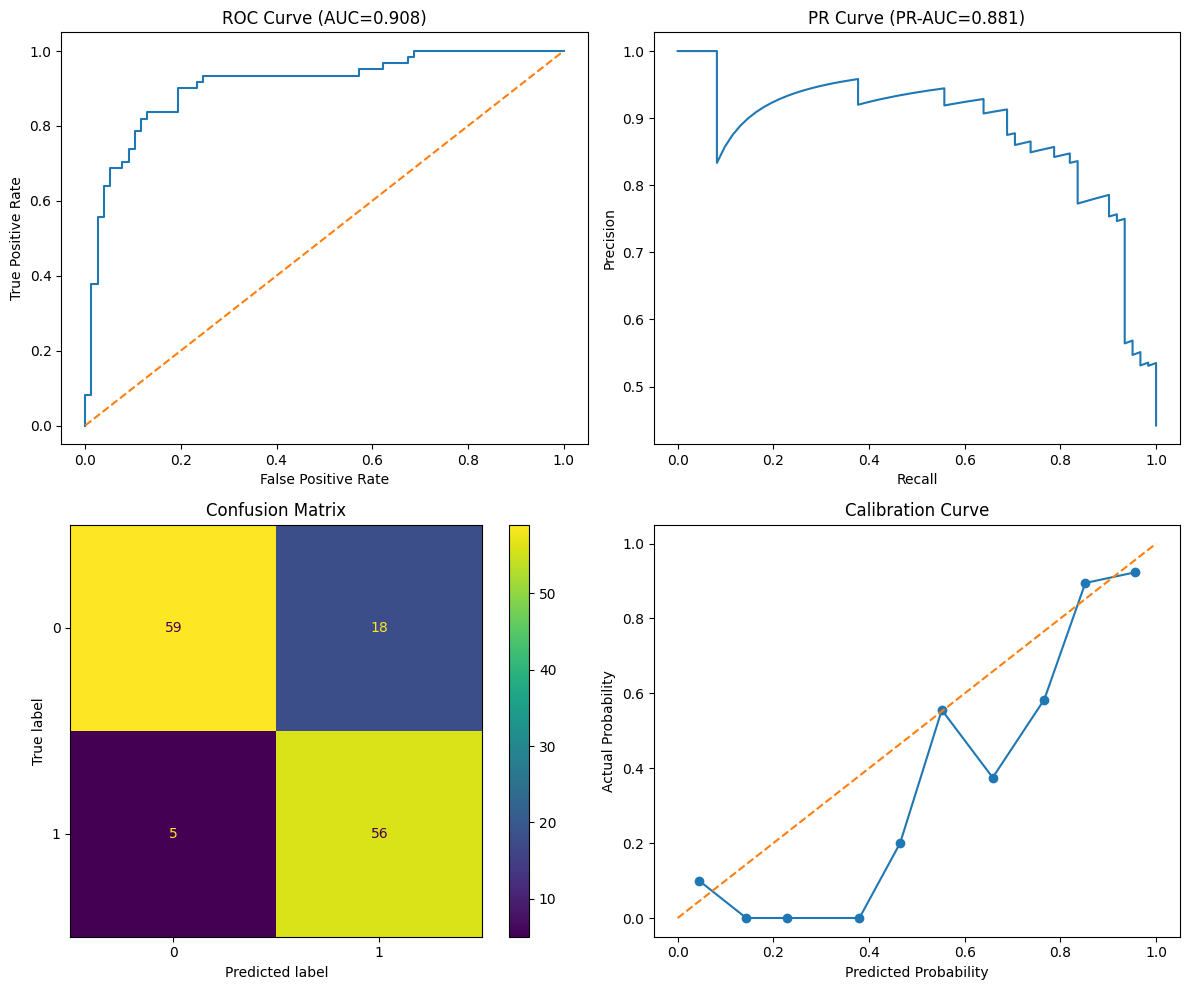

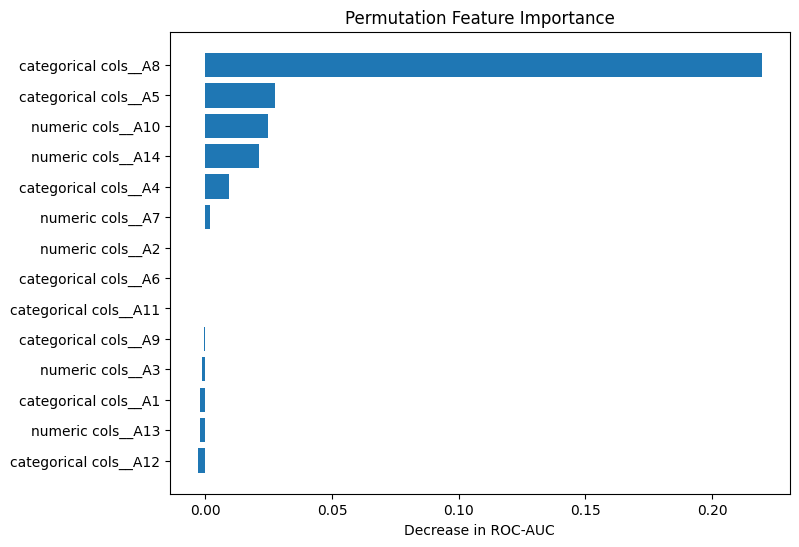

In [ ]:
metrics, feature_importance= evaluate_model(
    model=aus_base_lr,
    X_train=X_train_preprocessed,
    y_train=y_train,
    X_test=X_test_preprocessed,
    y_test=y_test
)

In [ ]:
# save_results_to_excel(
#     metrics_df=metrics,
#     dataset_name="Aus_Credit",
#     model_name="Base_Logistic_Regression",
#     params=aus_base_lr.get_params(),
#     comments="baseline model",
#     file_path = '/content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx'
# )

# Feature Selection

In [ ]:
df_train = pd.concat([X_train_preprocessed,y_train],axis=1)
df_train

,numeric cols__A13,numeric cols__A14,numeric cols__A2,numeric cols__A3,numeric cols__A7,numeric cols__A10,categorical cols__A1,categorical cols__A4,categorical cols__A5,categorical cols__A6,categorical cols__A8,categorical cols__A9,categorical cols__A11,categorical cols__A12,A15
293,1.156701,0.323025,-0.812243,-0.835013,-0.668315,-0.292009,1,1,14,4,1,1,1,2,1
333,0.688356,-0.637630,0.410194,-0.859901,-0.592595,-0.496045,1,1,9,4,0,0,1,2,0
284,0.704719,-0.882026,0.016441,-0.791457,0.379643,-0.496045,1,1,6,4,0,0,1,2,0
166,0.162086,1.816004,-0.712732,-0.428495,-0.654685,-0.496045,1,2,1,1,0,0,1,2,0
102,0.901286,1.066184,-0.318979,1.904835,1.061118,-0.496045,1,2,9,4,1,0,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522,0.400874,1.066184,-0.247777,-0.739605,-0.377552,-0.087972,0,2,11,4,1,1,1,2,0
431,0.246870,-0.882026,0.059333,-0.117384,-0.226113,-0.496045,1,1,13,4,0,0,1,2,0
502,0.820701,1.633934,1.396721,-0.428495,0.076765,1.952393,1,2,7,5,1,1,1,2,1
411,-2.003673,-0.882026,-0.884302,0.090023,-0.680430,-0.496045,0,1,1,1,0,0,0,2,0


In [ ]:
df_train.columns
num_cols = ['numeric cols__A13', 'numeric cols__A14', 'numeric cols__A2',
       'numeric cols__A3', 'numeric cols__A7', 'numeric cols__A10']
cat_cols = ['categorical cols__A1', 'categorical cols__A4', 'categorical cols__A5',
       'categorical cols__A6', 'categorical cols__A8', 'categorical cols__A9',
       'categorical cols__A11', 'categorical cols__A12']
target_col = ['A15']

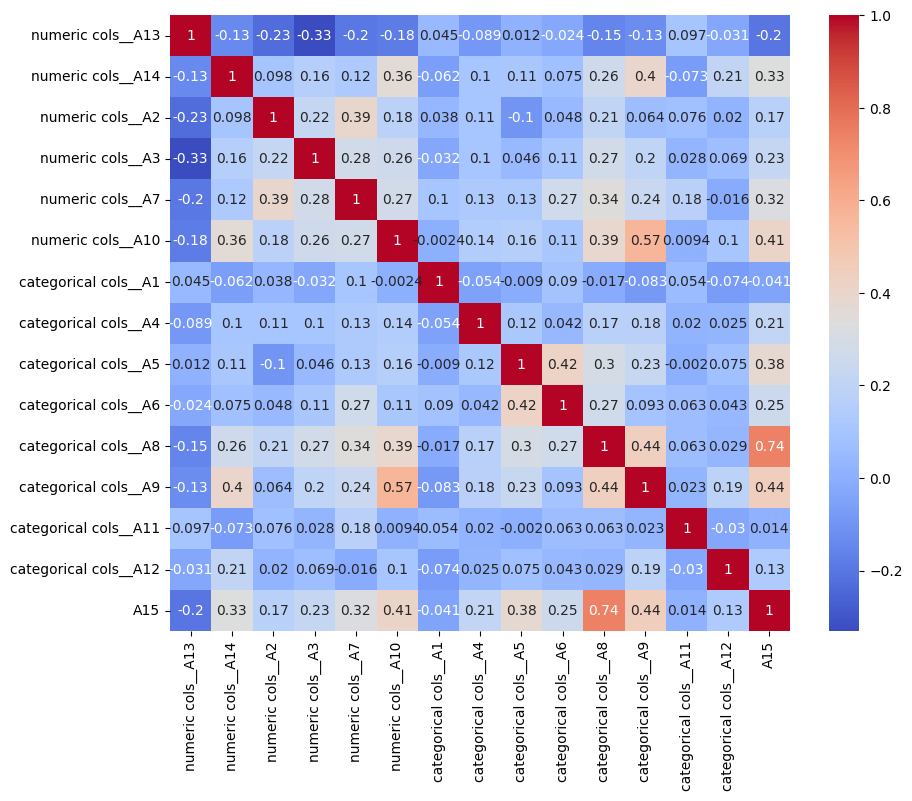

In [ ]:
corr_matrix = df_train.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,cmap = 'coolwarm')
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_train[num_cols]
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data.sort_values(by="VIF", ascending=False)

,Feature,VIF
4,numeric cols__A7,1.284555
5,numeric cols__A10,1.268724
3,numeric cols__A3,1.231508
2,numeric cols__A2,1.229519
0,numeric cols__A13,1.168839
1,numeric cols__A14,1.160023


In [ ]:
import pandas as pd
from scipy.stats import ttest_ind
results = []

for col in num_cols:

  group0 = df_train.loc[df_train['A15']==0, col].dropna()
  group1 = df_train.loc[df_train['A15']==1, col].dropna()

  t_stat, p_val = ttest_ind(group0, group1, equal_var=False)

  results.append({
            "feature": col,
            "t_statistic": t_stat,
            "p_value": p_val
    })

  results_df = pd.DataFrame(results)
results_df

# Here p_value < 0.05 means H0(variance may differ) can't be rejected.

,feature,t_statistic,p_value
0,numeric cols__A13,4.720582,3.149494e-06
1,numeric cols__A14,-7.877070,2.950487e-14
2,numeric cols__A2,-3.941866,9.316515e-05
3,numeric cols__A3,-5.318381,1.615720e-07
4,numeric cols__A7,-7.458829,6.564612e-13
5,numeric cols__A10,-9.657649,3.078271e-19


In [ ]:
from scipy.stats import chi2_contingency
results = []
for col in cat_cols:
    contingency_table = pd.crosstab(df_train[col], df_train[target_col[0]])

    chi, p, dof, expected = chi2_contingency(contingency_table)
    results.append({
        "feature":col,
        "chi":chi ,
        "p_value":p,
        "Flag": p < 0.05,
        "dof":dof,
        "expected":expected
    })
chi_results = pd.DataFrame(results)
chi_results

,feature,chi,p_value,Flag,dof,expected
0,categorical cols__A1,0.756639,3.843823e-01,False,1,"[[105.32608695652173, 84.67391304347827], [200..."
1,categorical cols__A4,25.557132,2.820585e-06,True,2,"[[71.51086956521739, 57.48913043478261], [233...."
2,categorical cols__A5,82.410683,3.874652e-12,True,13,"[[23.282608695652176, 18.717391304347824], [13..."
3,categorical cols__A6,38.103154,2.896367e-06,True,7,"[[26.054347826086957, 20.945652173913043], [2...."
4,categorical cols__A8,300.927325,2.068900e-67,True,1,"[[150.22826086956522, 120.77173913043478], [15..."
5,categorical cols__A9,107.488894,3.478492e-25,True,1,"[[173.5108695652174, 139.4891304347826], [132...."
6,categorical cols__A11,0.058876,8.082810e-01,False,1,"[[164.08695652173913, 131.91304347826087], [14..."
7,categorical cols__A12,9.668902,7.951051e-03,True,2,"[[25.5, 20.5], [277.17391304347825, 222.826086..."


In [ ]:
chi_columns = list (chi_results[chi_results['Flag']==False].feature)
for col in chi_columns:
  print(df_train[col].value_counts())

categorical cols__A1
1    362
0    190
Name: count, dtype: int64
categorical cols__A11
0    296
1    256
Name: count, dtype: int64


Based On all the above results it seems okay to drop A11 and A1. We will also check for both with removal and without removal. Model all the possibilities.

- After checking both the possibilities it is clear that there is no more impact on the performance of the models. we can remove the columns as they are also not helping to make it better.

In [ ]:
X_train_FS = X_train_preprocessed.drop(columns=['categorical cols__A1','categorical cols__A11'])
X_test_FS = X_test_preprocessed.drop(columns=['categorical cols__A1','categorical cols__A11'])

# Base Models

In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


base_models = {
    "Logistic Regression": LogisticRegression(),

    "SVM": SVC(probability=True),

    "KNN": KNeighborsClassifier(),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "XGBoost": XGBClassifier()
}

Training Logistic Regression


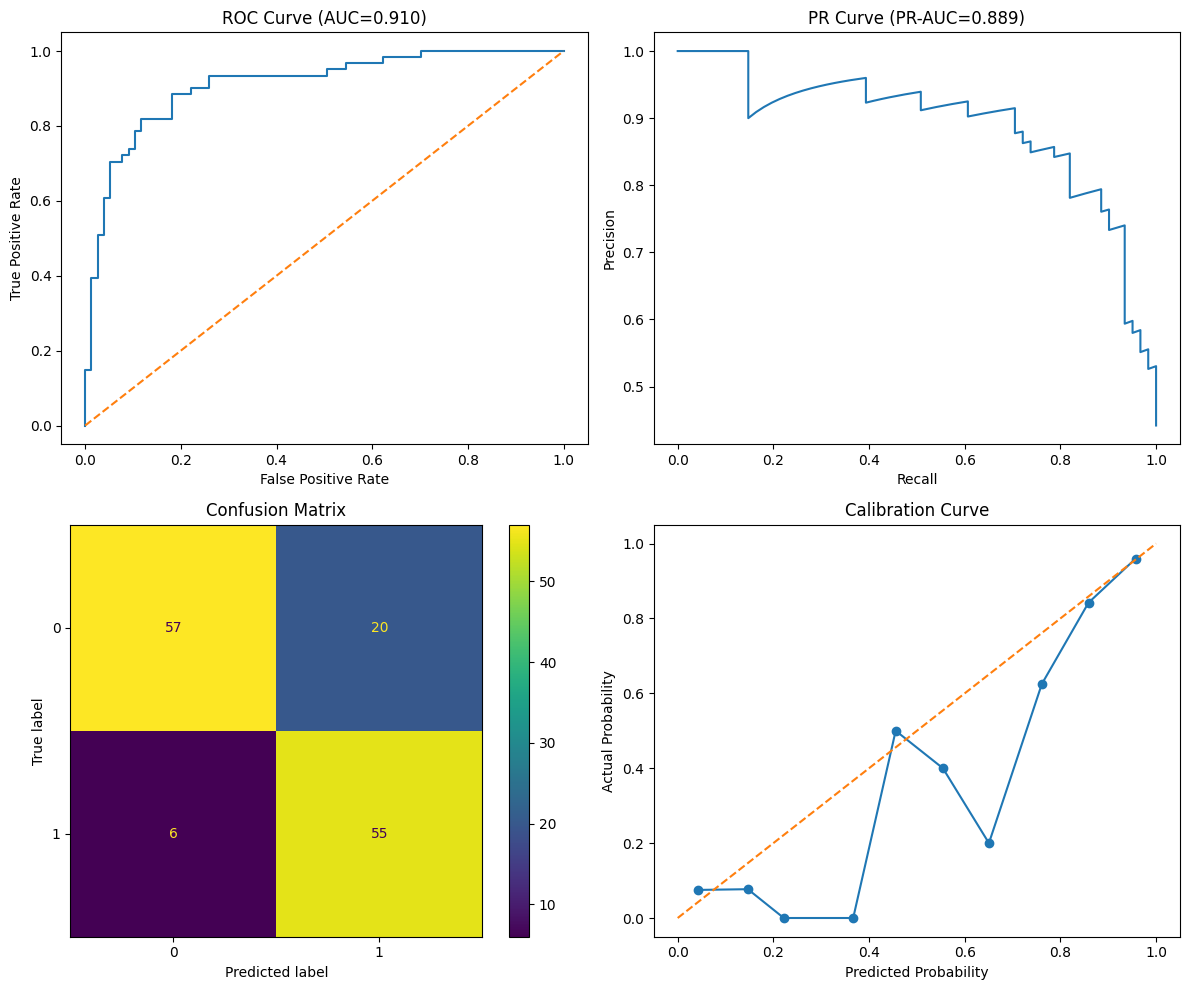

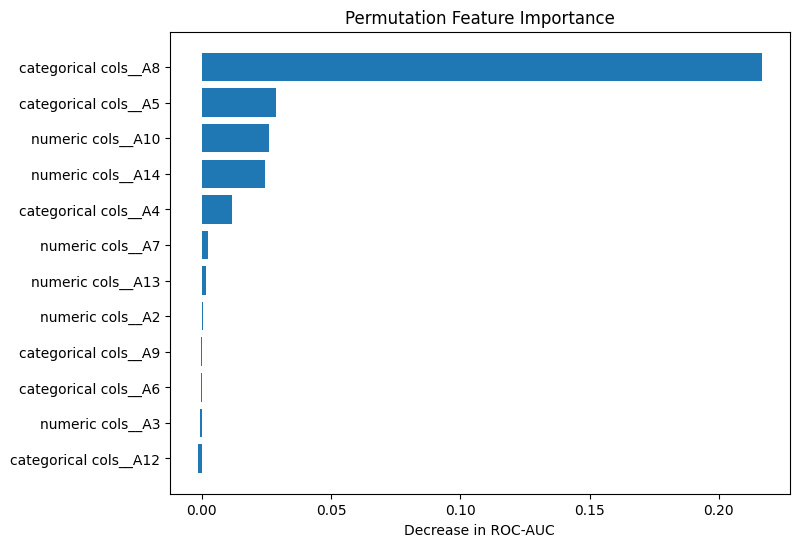

Results saved to /content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx
Training SVM


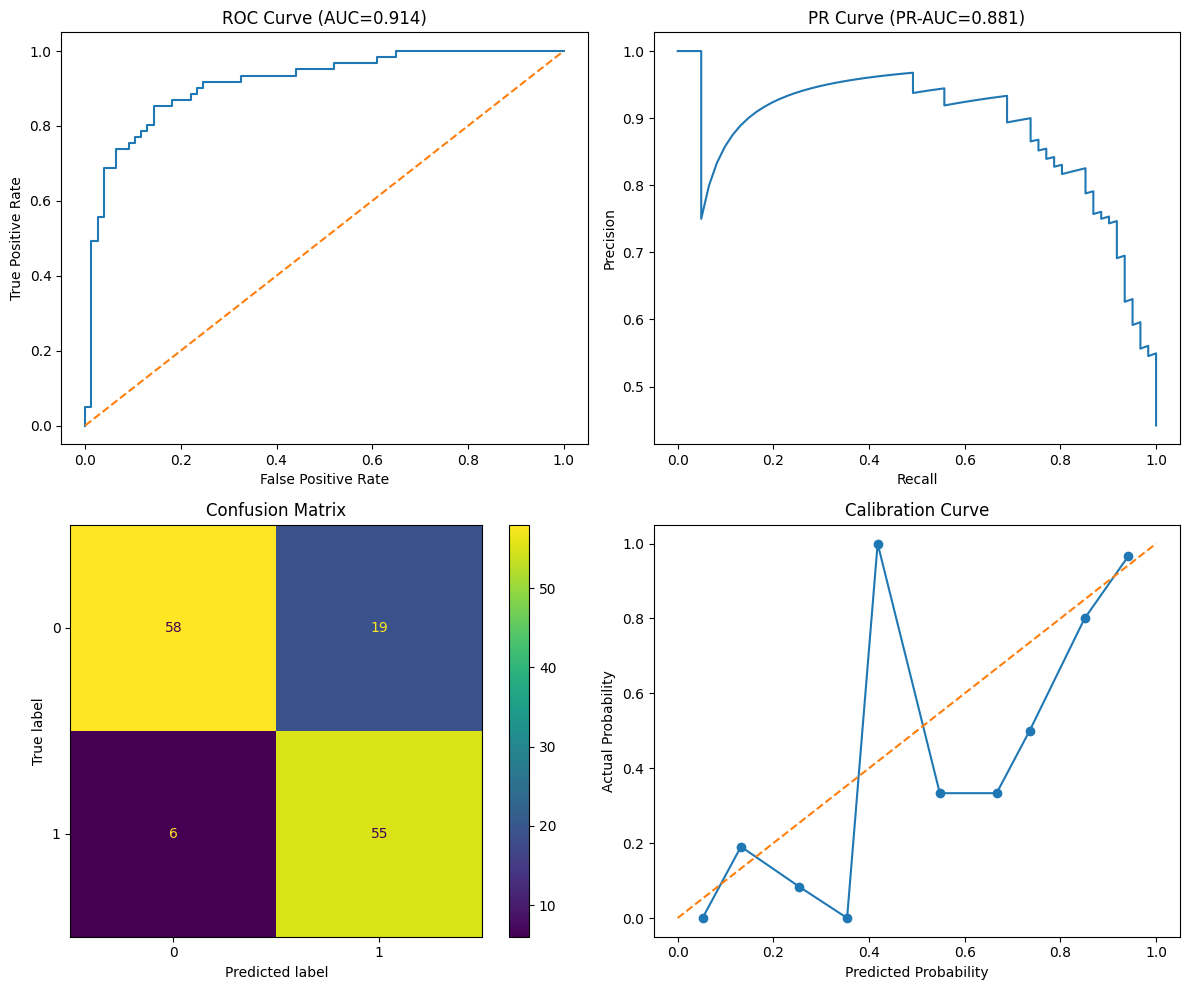

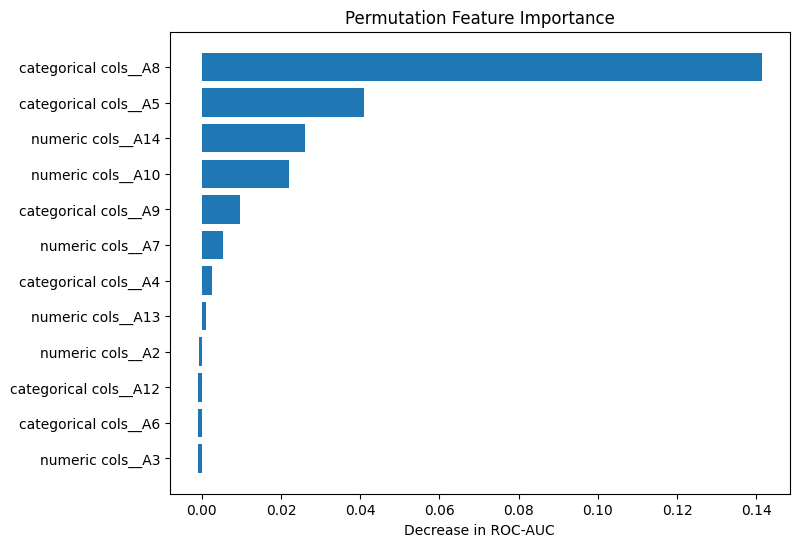

Results saved to /content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx
Training KNN


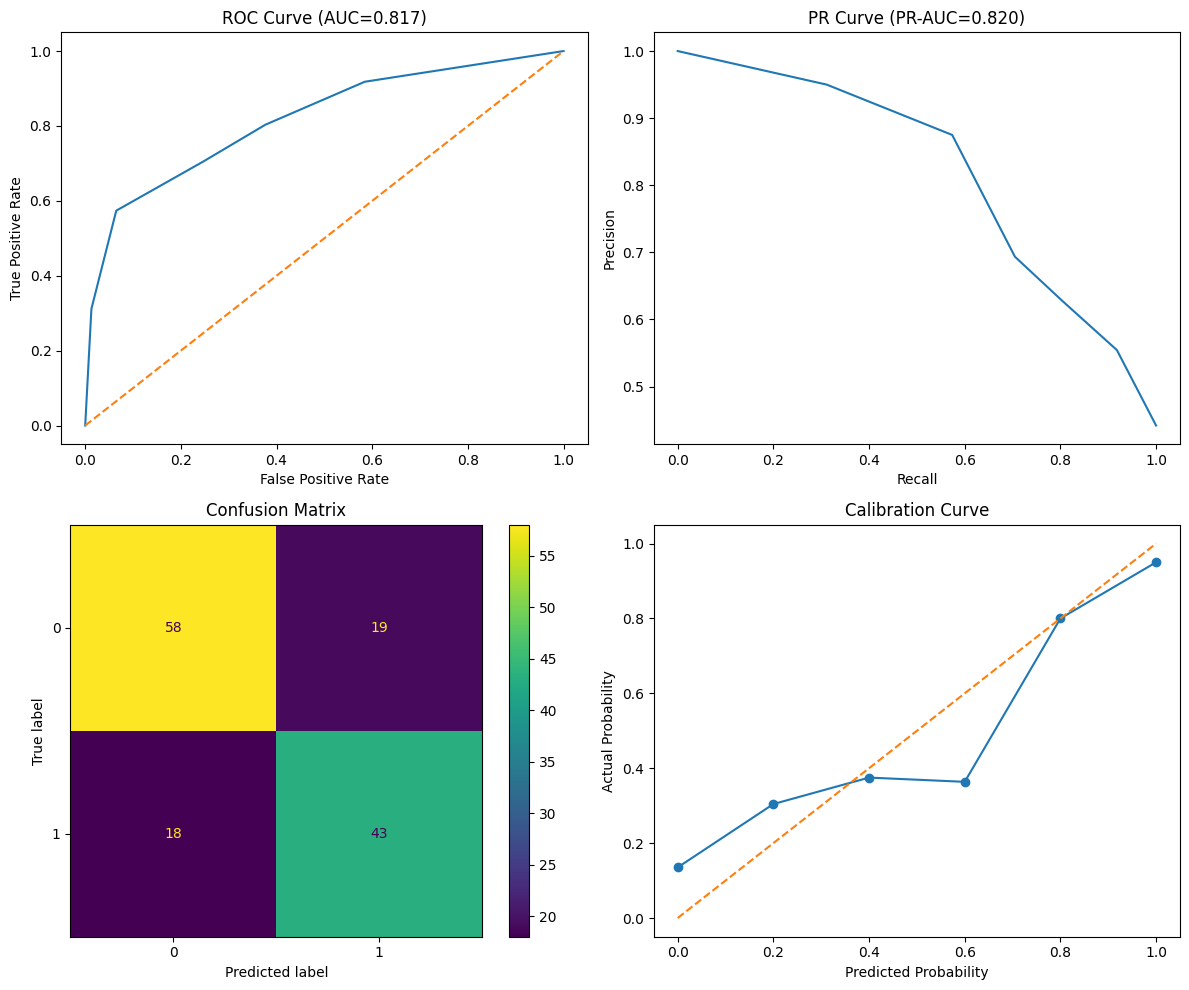

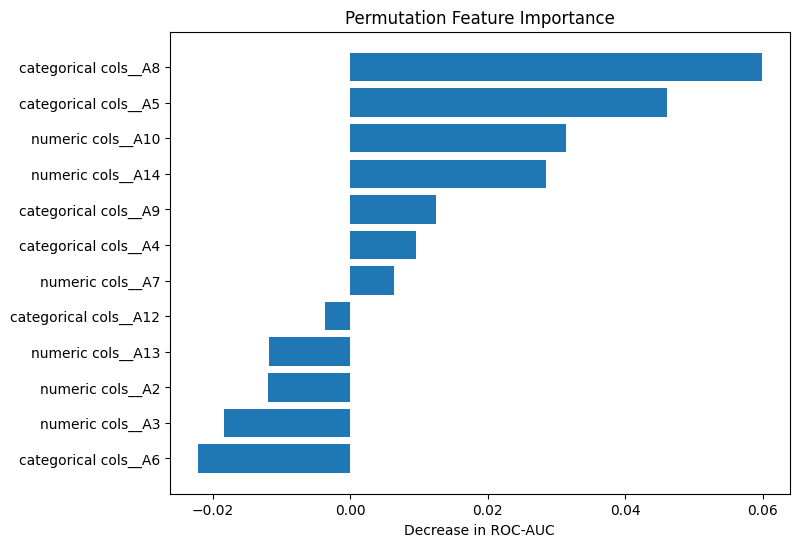

Results saved to /content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx
Training Decision Tree


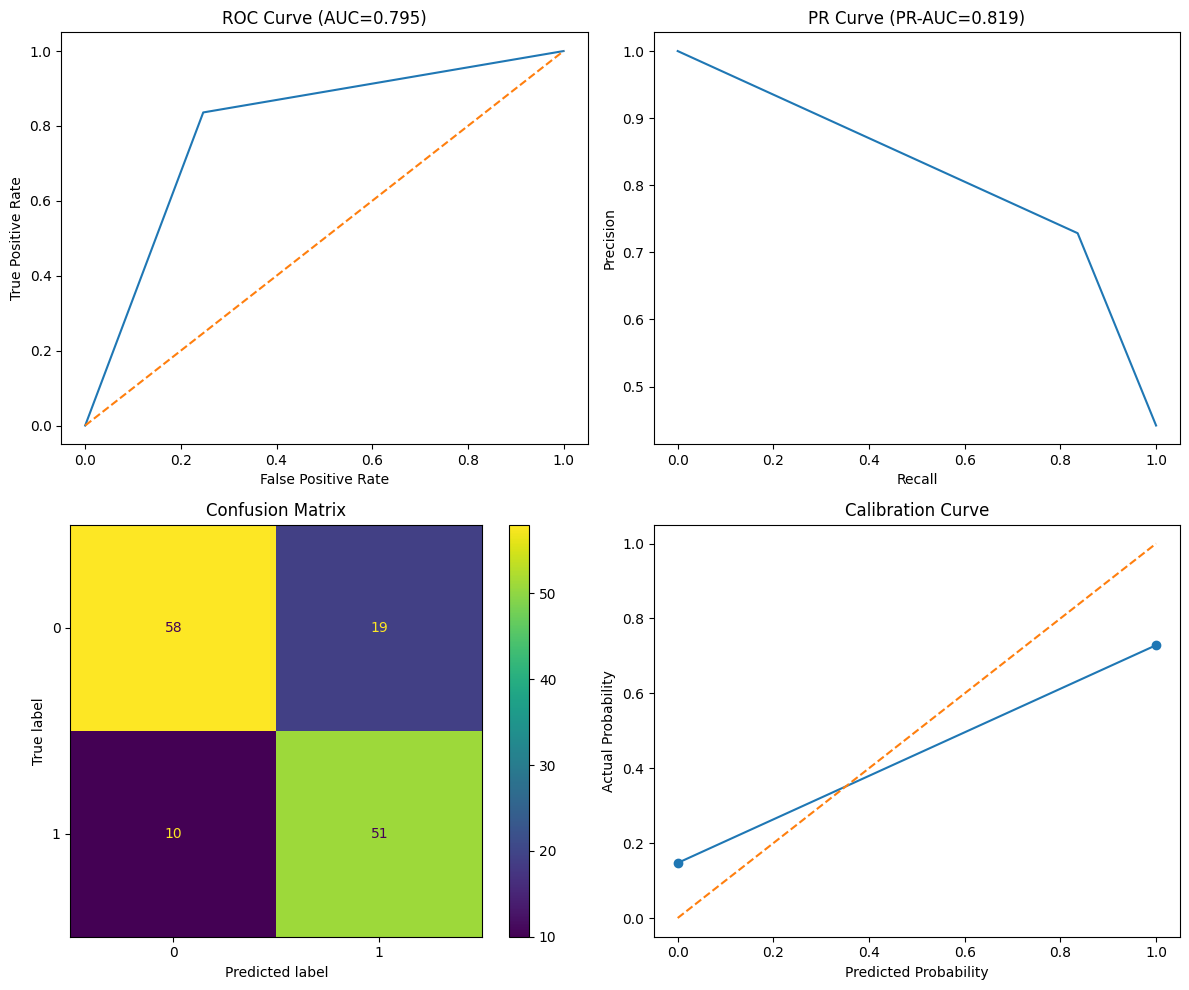

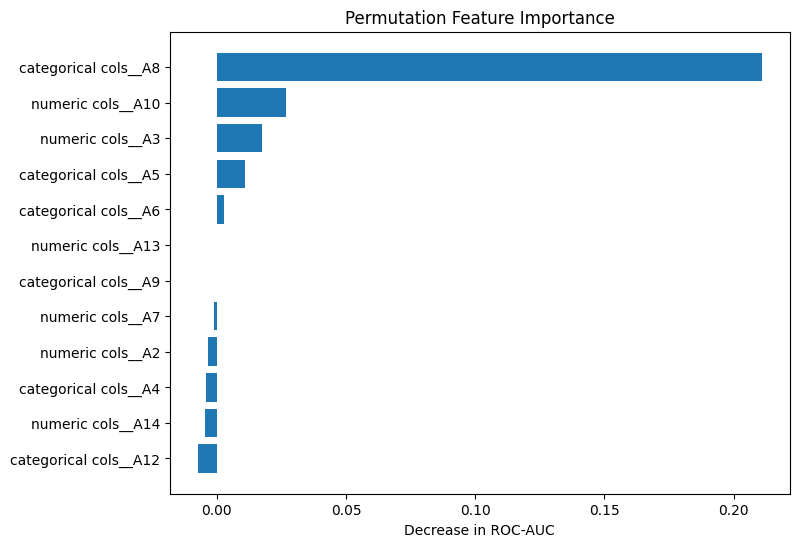

Results saved to /content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx
Training Random Forest


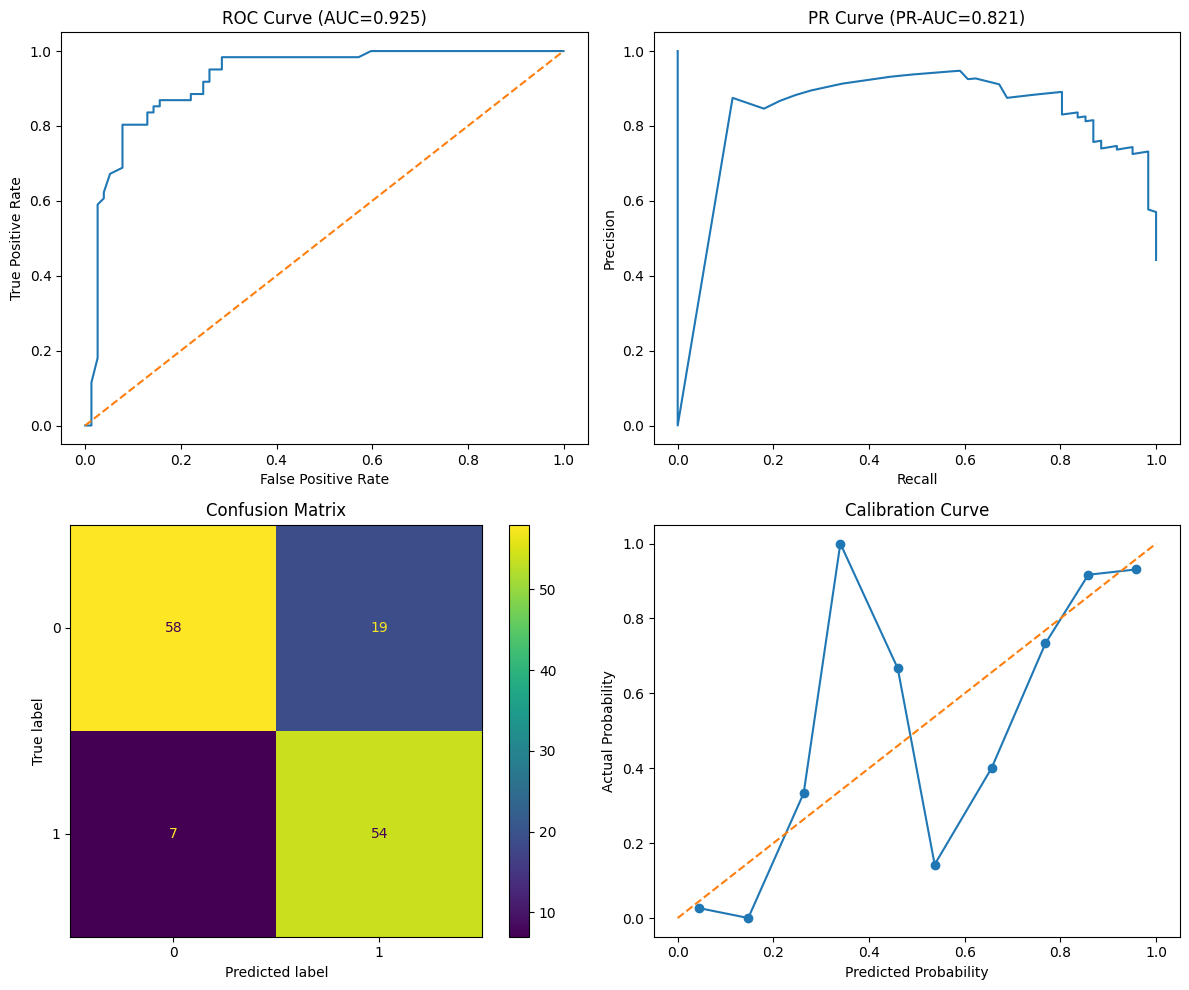

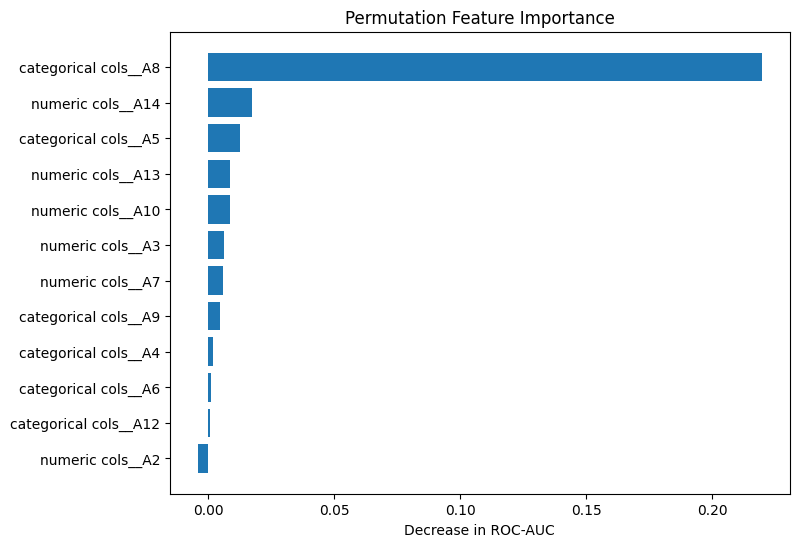

Results saved to /content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx
Training XGBoost


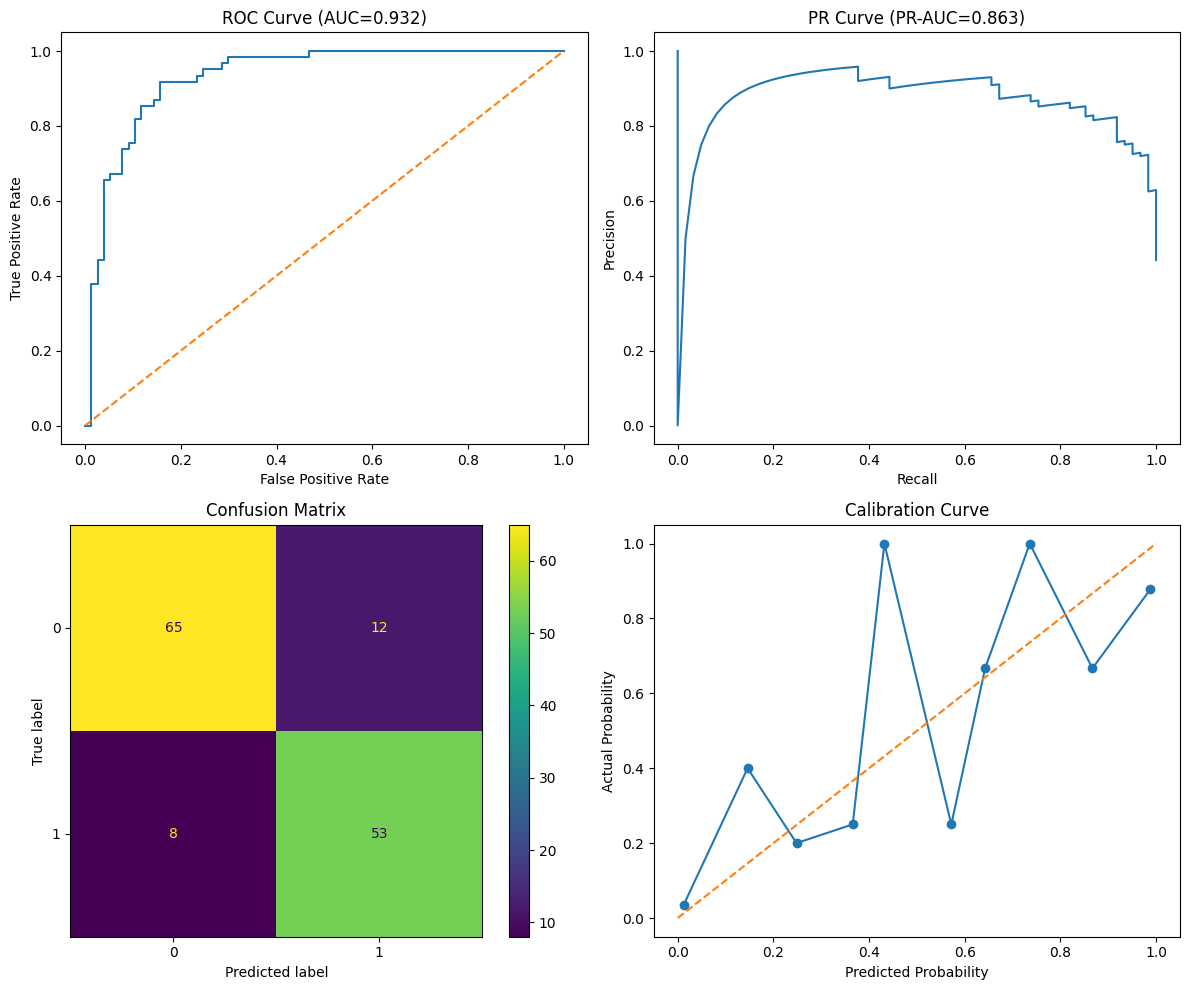

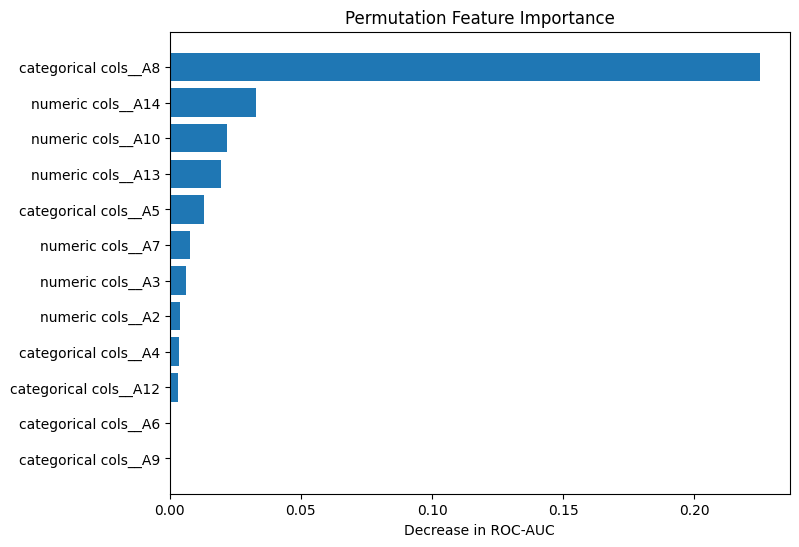

Results saved to /content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx


In [ ]:
all_results = []
feature_importance_df = pd.DataFrame()
all_results_df = pd.DataFrame()

for name, model in base_models.items():

    print(f"Training {name}")

    model.fit(X_train_FS, y_train)

    metrics, feature_importance = evaluate_model(
        model=model,
        X_train=X_train_FS,
        y_train=y_train,
        X_test=X_test_FS,
        y_test=y_test
)

#     save_results_to_excel(
#         metrics_df=metrics,
#         dataset_name="Aus_Credit",
#         model_name=f"Base_{name}",
#         params=model.get_params(),
#         comments="baseline model with Feature Selection",
#         file_path = '/content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx'
# )


    metrics = metrics.rename(columns={"Model_Evaluation":name})

    all_results_df = pd.concat([all_results_df,metrics],axis=1)

    renamed = {}
    for col in feature_importance.columns:
      renamed[col] = f"{name}_{col}"

    feature_importance = feature_importance.rename(columns=renamed)

    feature_importance_df = pd.concat([feature_importance_df,feature_importance],axis=1)


In [ ]:
# all_results_df.to_excel("/content/drive/MyDrive/credit_score_project/evaluation/Aus_base_models_FS.xlsx")

In [ ]:
# feature_importance_df.to_excel("/content/drive/MyDrive/credit_score_project/evaluation/Aus_base_models_FIMP_FS.xlsx")

# Logistic Regression

In [ ]:


kf = KFold(n_splits=5,shuffle=True, random_state=2)

logistic_params_random = [
    {
        "solver": ["saga"],
        "penalty": ["elasticnet"],
        "l1_ratio": [0, 0.25, 0.5, 0.75, 1],
        "C":[0.01,0.05,0.1,1,10,50,100],
        "class_weight": ["balanced", None]
    },
    {
        "solver": ["liblinear"],
        "penalty": ["l1", "l2"],
        "C":[0.01,0.05,0.1,1,10,50,100],
        "class_weight": ["balanced", None]
    },
    {
        "solver": ["lbfgs", "newton-cg"],
        "penalty": ["l2"],
       "C":[0.01,0.05,0.1,1,10,50,100],
        "class_weight": ["balanced", None]
    }
]


german_lr_r = LogisticRegression(max_iter=60000)


random_grid = RandomizedSearchCV(german_lr_r,logistic_params_random,n_iter=10,scoring='f1',cv=kf,verbose=1)
random_grid.fit(X_train_preprocessed,y_train)

results = pd.DataFrame(random_grid.cv_results_)
results.sort_values(by='mean_test_score',ascending=False)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_solver,param_penalty,param_l1_ratio,param_class_weight,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
2,0.013055,0.000736,0.005921,0.000400,saga,elasticnet,0.75,balanced,0.10,"{'solver': 'saga', 'penalty': 'elasticnet', 'l...",0.512000,0.500000,0.516129,0.583333,0.511628,0.524618,0.029845,1
8,0.003840,0.000097,0.003817,0.000258,liblinear,l2,NaN,balanced,0.10,"{'solver': 'liblinear', 'penalty': 'l2', 'clas...",0.508197,0.510204,0.520325,0.576271,0.492308,0.521461,0.028838,2
7,0.017177,0.003281,0.004065,0.000091,saga,elasticnet,1.00,balanced,1.00,"{'solver': 'saga', 'penalty': 'elasticnet', 'l...",0.495868,0.516129,0.516129,0.576271,0.480620,0.517003,0.032510,3
1,0.010526,0.001492,0.008022,0.001157,liblinear,l1,NaN,balanced,100.00,"{'solver': 'liblinear', 'penalty': 'l1', 'clas...",0.508475,0.483516,0.516129,0.561983,0.507692,0.515559,0.025668,4
6,0.003617,0.000111,0.003710,0.000116,liblinear,l1,NaN,balanced,0.05,"{'solver': 'liblinear', 'penalty': 'l1', 'clas...",0.524823,0.479339,0.519084,0.562963,0.488889,0.515019,0.029554,5
4,0.057766,0.016874,0.005710,0.001329,saga,elasticnet,1.00,None,50.00,"{'solver': 'saga', 'penalty': 'elasticnet', 'l...",0.309859,0.229508,0.324324,0.268657,0.278481,0.282166,0.033206,6
9,0.005513,0.000514,0.004117,0.000204,liblinear,l1,NaN,None,100.00,"{'solver': 'liblinear', 'penalty': 'l1', 'clas...",0.309859,0.229508,0.324324,0.268657,0.278481,0.282166,0.033206,6
5,0.005600,0.000275,0.004066,0.000339,liblinear,l1,NaN,None,50.00,"{'solver': 'liblinear', 'penalty': 'l1', 'clas...",0.309859,0.229508,0.324324,0.268657,0.278481,0.282166,0.033206,6
0,0.050147,0.007976,0.007470,0.001956,saga,elasticnet,0.00,None,10.00,"{'solver': 'saga', 'penalty': 'elasticnet', 'l...",0.309859,0.225806,0.324324,0.268657,0.278481,0.281426,0.034392,9
3,0.012061,0.001550,0.006806,0.000780,saga,elasticnet,0.50,None,0.01,"{'solver': 'saga', 'penalty': 'elasticnet', 'l...",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10


In [ ]:
# From the randomsearch result we can narrow down to which parameters needs
# further tunning

logistic_params = [
    {
  "solver": ["liblinear"],
  "C":[10,50,100],
  "penalty":["l1","l2"]
    },
     {
    "solver": ["newton-cg"],
        "penalty": ["l2"],
       "C":[10,50,100]
    }
]


german_lr = LogisticRegression(max_iter=70000,class_weight='balanced')
gridsearch = GridSearchCV(german_lr,logistic_params,scoring='precision',cv=kf,verbose=1)
gridsearch.fit(X_train_preprocessed,y_train)

results = pd.DataFrame(gridsearch.cv_results_)
results.sort_values(by='mean_test_score',ascending=False)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


KeyboardInterrupt: 

In [ ]:
german_lr_final = LogisticRegression(max_iter=5000,solver='liblinear',penalty='l2',C=0.05,class_weight='balanced')


german_lr_final.fit(X_train_preprocessed,y_train)

metrics, feature_importance = evaluate_model(
        model=german_lr_final,
        X_train=X_train_preprocessed,
        y_train=y_train,
        X_test=X_test_preprocessed,
        y_test=y_test,
        threshold=0.5
)

In [ ]:
print(old_metrics)

In [ ]:
print(old_metrics.loc["classification_report","Model_Evaluation"])

In [ ]:
print(metrics.loc["classification_report","Model_Evaluation"])

In [ ]:
metrics

# SVM

In [ ]:
from sklearn.svm import SVC
german_svm =  SVC(probability=False)
kf = KFold(n_splits=5,shuffle=True, random_state=2)

In [ ]:
from scipy.stats import loguniform
svm_params_random = [

    {
        "kernel": ["linear"],
        "C": [0.001,1,10,50,100,1000]
    },

    {
        "kernel": ["rbf"],
        "C": [0.01,0.1,0.5,1,10,100],
        "gamma": [0.001,0.01,0.05,0.1,0.005,0.003,0.3,1]
    }
]

svm_params_set1 = {
        "kernel": ["rbf"],
        "C": loguniform(1e-3, 1e3),
        "gamma": loguniform(1e-4, 1e1)
    }



In [ ]:
random_grid = RandomizedSearchCV(german_svm,
                                 svm_params_set1,
                                 n_iter=50,
                                 scoring='roc_auc',
                                 cv=kf,verbose=1)
random_grid.fit(X_train_preprocessed,y_train)

results = pd.DataFrame(random_grid.cv_results_)
results.sort_values(by='mean_test_score',ascending=False)


Fitting 5 folds for each of 50 candidates, totalling 250 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
5,0.066318,0.004535,0.026788,0.001014,6.088469,0.072926,rbf,"{'C': 6.088469232099255, 'gamma': 0.0729260177...",0.717567,0.755851,0.737986,0.750138,0.750343,0.742377,0.013712,1
2,0.032892,0.006406,0.015630,0.004859,0.902009,0.080773,rbf,"{'C': 0.9020094186579863, 'gamma': 0.080772630...",0.722463,0.734262,0.749619,0.755286,0.749313,0.742188,0.012078,2
16,0.025456,0.000421,0.013843,0.000743,0.054920,0.097142,rbf,"{'C': 0.05491952667054223, 'gamma': 0.09714170...",0.720203,0.728006,0.750953,0.755470,0.746394,0.740205,0.013680,3
32,0.027506,0.001005,0.012688,0.000470,1.181217,0.054852,rbf,"{'C': 1.1812171739132062, 'gamma': 0.054852386...",0.722651,0.730024,0.744279,0.750506,0.750687,0.739629,0.011338,4
27,0.028384,0.001627,0.013354,0.000807,2.701399,0.047976,rbf,"{'C': 2.7013989825188833, 'gamma': 0.047976267...",0.713802,0.735472,0.745042,0.750506,0.750343,0.739033,0.013747,5
25,0.025627,0.001745,0.012460,0.000401,0.006786,0.167412,rbf,"{'C': 0.006786276937429896, 'gamma': 0.1674118...",0.720392,0.740517,0.748284,0.745725,0.738496,0.738683,0.009795,6
38,0.016783,0.000989,0.008019,0.000546,1.113184,0.041576,rbf,"{'C': 1.1131837150010484, 'gamma': 0.041575635...",0.717756,0.729621,0.742944,0.747196,0.751889,0.737881,0.012505,7
49,0.014193,0.000585,0.007486,0.000101,0.001293,0.111623,rbf,"{'C': 0.001293453031494455, 'gamma': 0.1116232...",0.717756,0.722559,0.742754,0.750689,0.738152,0.734382,0.012381,8
30,0.023837,0.000994,0.012666,0.000544,0.001392,0.241957,rbf,"{'C': 0.0013916205494795477, 'gamma': 0.241956...",0.722275,0.747175,0.739321,0.726420,0.726992,0.732437,0.009314,9
46,0.014527,0.000374,0.007807,0.000409,0.005213,0.040367,rbf,"{'C': 0.00521269625934984, 'gamma': 0.04036663...",0.711542,0.728612,0.724066,0.743335,0.754464,0.732404,0.015002,10


In [ ]:
svm_params_set2 = {
        "kernel": ["rbf"],
        "C": [10,5,3,1,0.5,0.3,0.1,0.01,0.06,0.09,0.2],
        "gamma": [0.05,0.045,0.04,0.035,0.03,0.25,0.02,0.015,0.01,0.1,1]
    }

gridsearch = GridSearchCV(german_svm,svm_params_set2,scoring='roc_auc',cv=kf,verbose=1)
gridsearch.fit(X_train_preprocessed,y_train)

results = pd.DataFrame(gridsearch.cv_results_)
results.sort_values(by='mean_test_score',ascending=False)

Fitting 5 folds for each of 121 candidates, totalling 605 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
11,0.141393,0.005885,0.013437,0.001194,5.0,0.050,rbf,"{'C': 5, 'gamma': 0.05, 'kernel': 'rbf'}",0.713425,0.752018,0.747712,0.754183,0.749313,0.743330,0.015117,1
42,0.082464,0.004387,0.009000,0.002122,1.0,0.100,rbf,"{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}",0.720392,0.740718,0.751335,0.757492,0.745021,0.742992,0.012648,2
1,0.187688,0.019189,0.018660,0.004462,10.0,0.045,rbf,"{'C': 10, 'gamma': 0.045, 'kernel': 'rbf'}",0.712860,0.755246,0.742754,0.753631,0.750000,0.742898,0.015623,3
2,0.165146,0.024370,0.015425,0.005693,10.0,0.040,rbf,"{'C': 10, 'gamma': 0.04, 'kernel': 'rbf'}",0.710224,0.751412,0.745042,0.753263,0.750515,0.742091,0.016167,4
31,0.083815,0.002071,0.008065,0.000481,3.0,0.100,rbf,"{'C': 3, 'gamma': 0.1, 'kernel': 'rbf'}",0.714555,0.756053,0.744851,0.750873,0.743647,0.741996,0.014424,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43,0.113712,0.001225,0.010338,0.000737,1.0,1.000,rbf,"{'C': 1, 'gamma': 1, 'kernel': 'rbf'}",0.666353,0.710048,0.685736,0.705277,0.655735,0.684630,0.021178,117
5,0.114456,0.006338,0.008069,0.000225,10.0,0.250,rbf,"{'C': 10, 'gamma': 0.25, 'kernel': 'rbf'}",0.631708,0.715496,0.669336,0.683765,0.699863,0.680034,0.028686,118
32,0.120395,0.005734,0.009816,0.000669,3.0,1.000,rbf,"{'C': 3, 'gamma': 1, 'kernel': 'rbf'}",0.635097,0.709443,0.669336,0.657658,0.655391,0.665385,0.024632,119
21,0.120534,0.002690,0.010760,0.002440,5.0,1.000,rbf,"{'C': 5, 'gamma': 1, 'kernel': 'rbf'}",0.641875,0.705004,0.660946,0.653061,0.652816,0.662740,0.021986,120


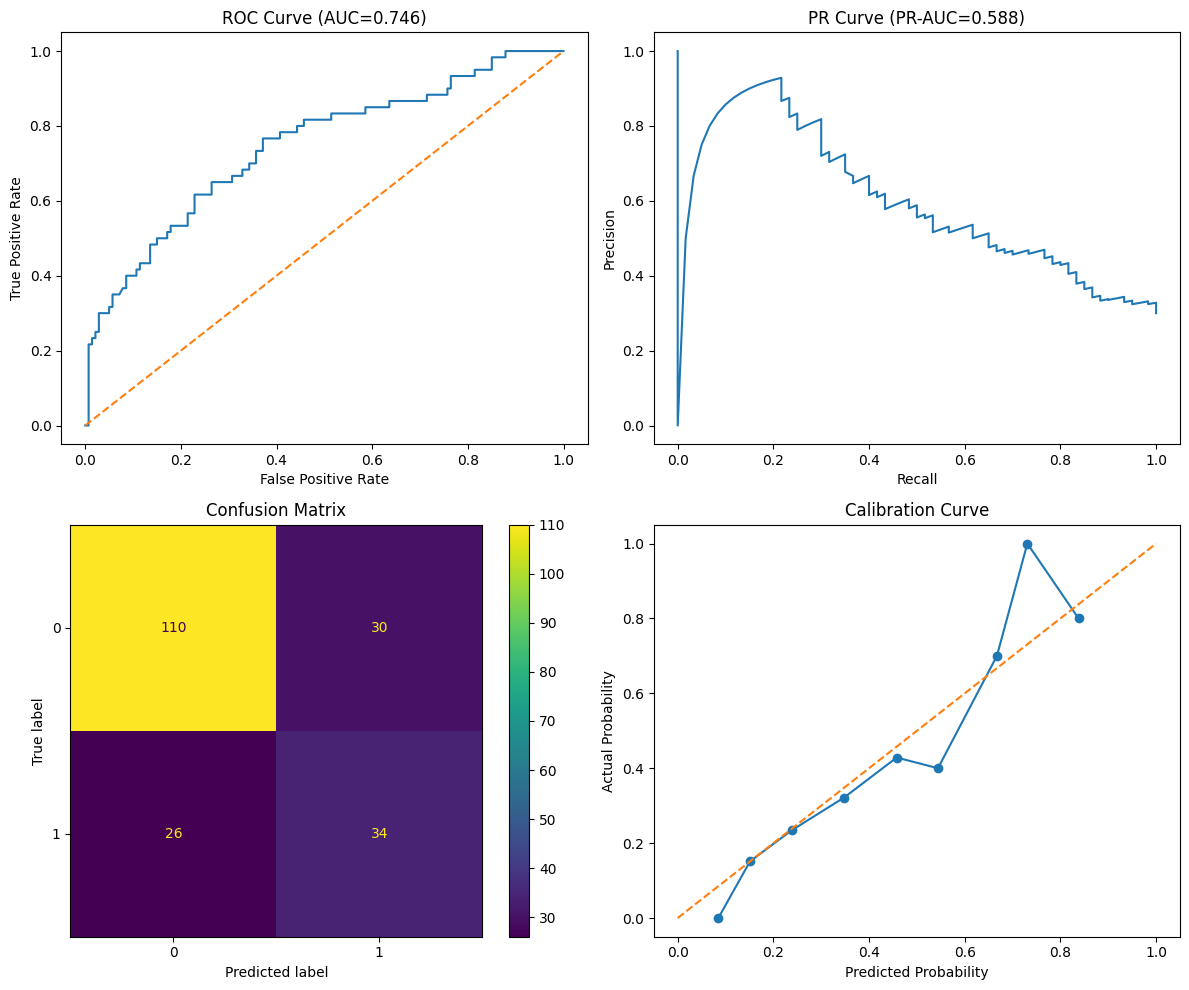

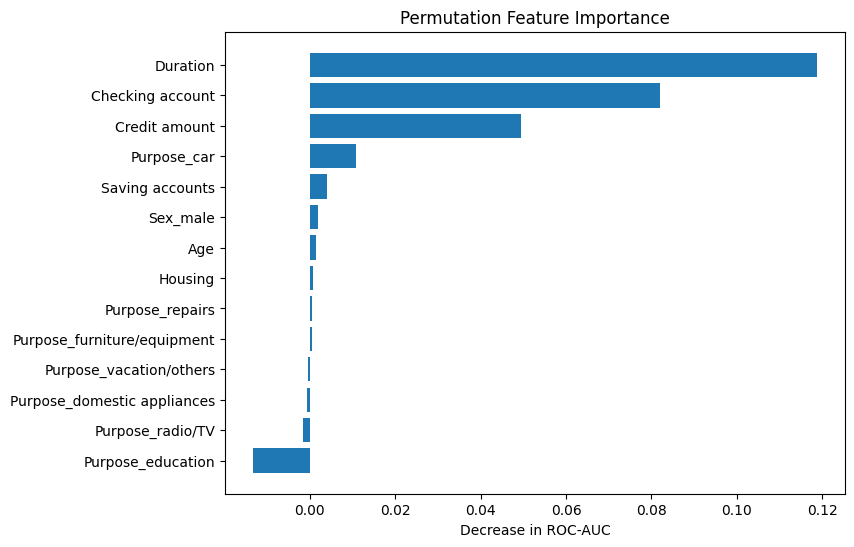

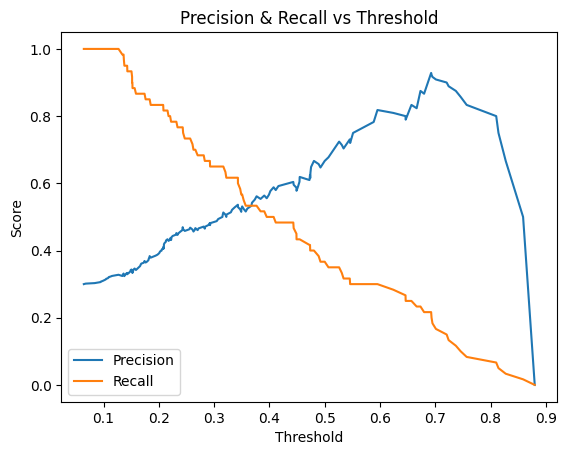

In [ ]:
german_svm_set1 = SVC(probability=True,C= 5, gamma= 0.05, kernel= 'rbf')

# german_svm_final = SVC(probability=True,C= 5, gamma= 0.05, kernel= 'rbf')
german_svm_set1.fit(X_train_preprocessed,y_train)

metrics, feature_importance = evaluate_model(
        model=german_svm_set1,
        X_train=X_train_preprocessed,
        y_train=y_train,
        X_test=X_test_preprocessed,
        y_test=y_test,
        threshold=0.35
)

In [ ]:
metrics

,Model_Evaluation
class_weight_train,"Risk\n0 0.7\n1 0.3\nName: proportion, dt..."
class_weight_test,"Risk\n0 0.7\n1 0.3\nName: proportion, dt..."
ROC_AUC_train,0.829613
ROC_AUC_test,0.745536
Gini,0.491071
PR_AUC,0.58813
KS,0.395238
LogLoss,0.518816
BrierScore,0.170491
Accuracy,0.72


# KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

german_knn = KNeighborsClassifier()
kf = KFold(n_splits=5,shuffle=True, random_state=2)

In [ ]:
k_values = range(1, 51)

auc_scores = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        knn,
        X_train_preprocessed,
        y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    )

    auc_scores.append(scores.mean())

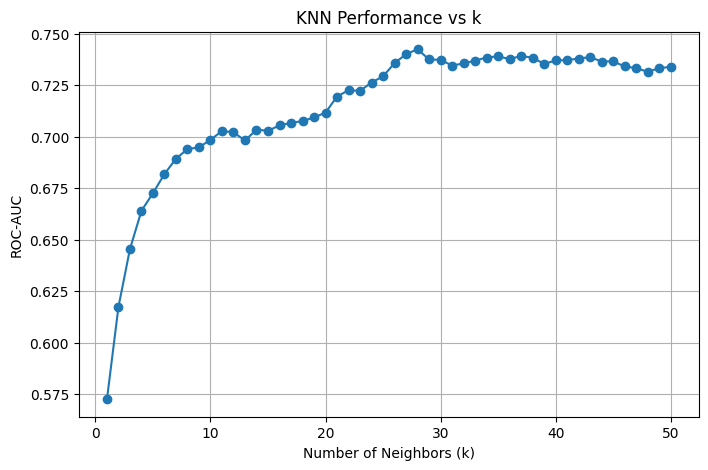

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(k_values, auc_scores, marker="o")

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("ROC-AUC")
plt.title("KNN Performance vs k")

plt.grid(True)

plt.show()

In [ ]:
from scipy.stats import randint

knn_param_set1 = {

    "n_neighbors": randint(10, 30),

    "weights": ["uniform", "distance"],

    "metric": ["minkowski"],

    "p": [1, 2],

    "leaf_size": randint(20, 60)
}
knn_param_set2 =  {   "n_neighbors": [25,26,27,28,29,30,31,32,33,35,40],

    "weights": ["distance"],

    "metric": ["minkowski"],

    "p": [2],

    "leaf_size": [35,40,45,50,55,60,65]}

In [ ]:
random_grid = RandomizedSearchCV(german_knn,
                                 knn_param_set1,
                                 n_iter=50,
                                 scoring='f1',
                                 cv=kf,verbose=1)
random_grid.fit(X_train_preprocessed,y_train)

results = pd.DataFrame(random_grid.cv_results_)
results.sort_values(by='mean_test_score',ascending=False)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_leaf_size,param_metric,param_n_neighbors,param_p,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
19,0.011318,0.001447,0.026424,0.005836,25,minkowski,12,2,distance,"{'leaf_size': 25, 'metric': 'minkowski', 'n_ne...",0.297297,0.382353,0.493827,0.581395,0.461538,0.443282,0.096940,1
7,0.012564,0.003082,0.035320,0.008336,24,minkowski,14,1,distance,"{'leaf_size': 24, 'metric': 'minkowski', 'n_ne...",0.368421,0.434783,0.480000,0.525000,0.404494,0.442540,0.055144,2
25,0.006583,0.002144,0.020426,0.003654,25,minkowski,14,1,distance,"{'leaf_size': 25, 'metric': 'minkowski', 'n_ne...",0.368421,0.434783,0.480000,0.525000,0.404494,0.442540,0.055144,2
17,0.010454,0.001421,0.031915,0.006466,55,minkowski,15,1,distance,"{'leaf_size': 55, 'metric': 'minkowski', 'n_ne...",0.342105,0.428571,0.487179,0.545455,0.409091,0.442480,0.069261,4
43,0.004832,0.000137,0.014426,0.002674,22,minkowski,11,1,distance,"{'leaf_size': 22, 'metric': 'minkowski', 'n_ne...",0.394737,0.441176,0.435897,0.493827,0.382022,0.429532,0.039441,5
26,0.010660,0.002342,0.028809,0.002418,46,minkowski,11,1,distance,"{'leaf_size': 46, 'metric': 'minkowski', 'n_ne...",0.394737,0.441176,0.435897,0.493827,0.382022,0.429532,0.039441,5
23,0.010837,0.000899,0.028962,0.001421,36,minkowski,16,1,distance,"{'leaf_size': 36, 'metric': 'minkowski', 'n_ne...",0.342105,0.400000,0.467532,0.526316,0.409091,0.429009,0.062838,7
14,0.006162,0.002505,0.017405,0.005032,38,minkowski,12,1,distance,"{'leaf_size': 38, 'metric': 'minkowski', 'n_ne...",0.328767,0.417910,0.487179,0.506024,0.404494,0.428875,0.063384,8
40,0.004526,0.000286,0.013412,0.000834,59,minkowski,12,1,distance,"{'leaf_size': 59, 'metric': 'minkowski', 'n_ne...",0.328767,0.417910,0.487179,0.506024,0.404494,0.428875,0.063384,8
47,0.004803,0.000175,0.014374,0.001331,53,minkowski,21,1,distance,"{'leaf_size': 53, 'metric': 'minkowski', 'n_ne...",0.358974,0.388060,0.461538,0.540541,0.376471,0.425117,0.067474,10


In [ ]:
gridsearch = GridSearchCV(german_knn,knn_param_set2,scoring='f1',cv=kf,verbose=1)
gridsearch.fit(X_train_preprocessed,y_train)

results = pd.DataFrame(gridsearch.cv_results_)
results.sort_values(by='mean_test_score',ascending=False)

Fitting 5 folds for each of 77 candidates, totalling 385 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_leaf_size,param_metric,param_n_neighbors,param_p,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1,0.004825,0.000109,0.013188,0.000246,35,minkowski,26,2,distance,"{'leaf_size': 35, 'metric': 'minkowski', 'n_ne...",0.342857,0.338462,0.411765,0.506667,0.370370,0.394024,0.062077,1
12,0.005403,0.001305,0.014228,0.003176,40,minkowski,26,2,distance,"{'leaf_size': 40, 'metric': 'minkowski', 'n_ne...",0.342857,0.338462,0.411765,0.506667,0.370370,0.394024,0.062077,1
56,0.017802,0.003699,0.049623,0.006872,60,minkowski,26,2,distance,"{'leaf_size': 60, 'metric': 'minkowski', 'n_ne...",0.342857,0.338462,0.411765,0.506667,0.370370,0.394024,0.062077,1
34,0.010866,0.001226,0.030361,0.001642,50,minkowski,26,2,distance,"{'leaf_size': 50, 'metric': 'minkowski', 'n_ne...",0.342857,0.338462,0.411765,0.506667,0.370370,0.394024,0.062077,1
23,0.010675,0.006630,0.022039,0.013752,45,minkowski,26,2,distance,"{'leaf_size': 45, 'metric': 'minkowski', 'n_ne...",0.342857,0.338462,0.411765,0.506667,0.370370,0.394024,0.062077,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32,0.008689,0.005596,0.023455,0.008370,45,minkowski,40,2,distance,"{'leaf_size': 45, 'metric': 'minkowski', 'n_ne...",0.294118,0.266667,0.327869,0.375000,0.293333,0.311397,0.037262,71
43,0.005841,0.002787,0.016866,0.006184,50,minkowski,40,2,distance,"{'leaf_size': 50, 'metric': 'minkowski', 'n_ne...",0.294118,0.266667,0.327869,0.375000,0.293333,0.311397,0.037262,71
54,0.014973,0.002481,0.041845,0.002598,55,minkowski,40,2,distance,"{'leaf_size': 55, 'metric': 'minkowski', 'n_ne...",0.294118,0.266667,0.327869,0.375000,0.293333,0.311397,0.037262,71
65,0.010148,0.001598,0.028581,0.004740,60,minkowski,40,2,distance,"{'leaf_size': 60, 'metric': 'minkowski', 'n_ne...",0.294118,0.266667,0.327869,0.375000,0.293333,0.311397,0.037262,71


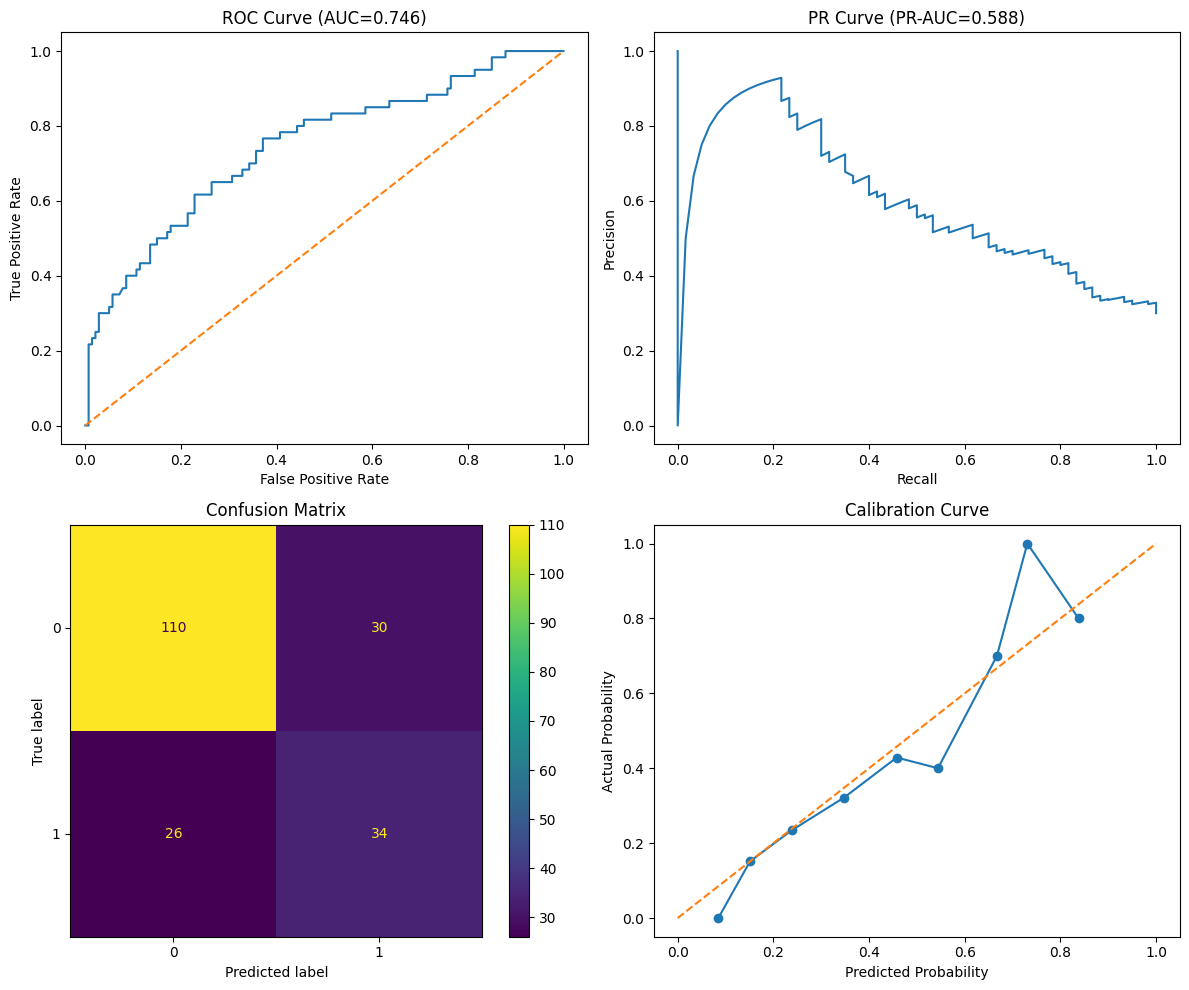

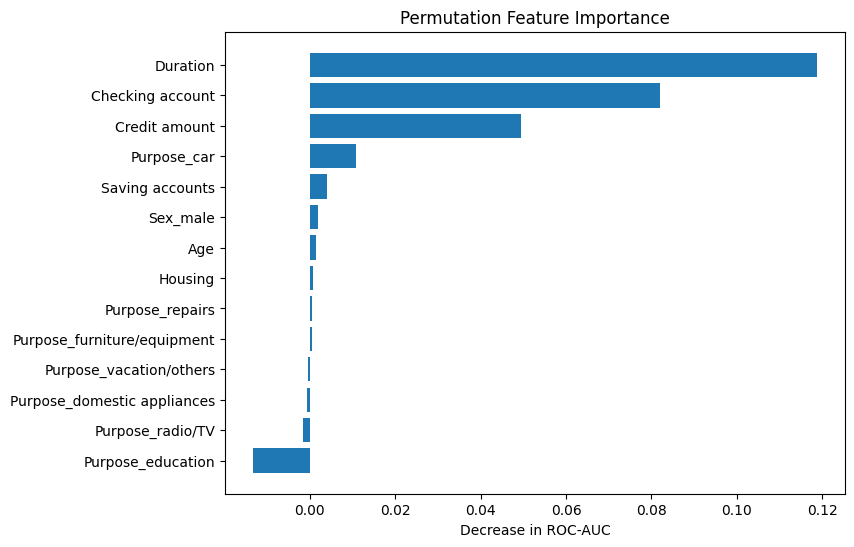

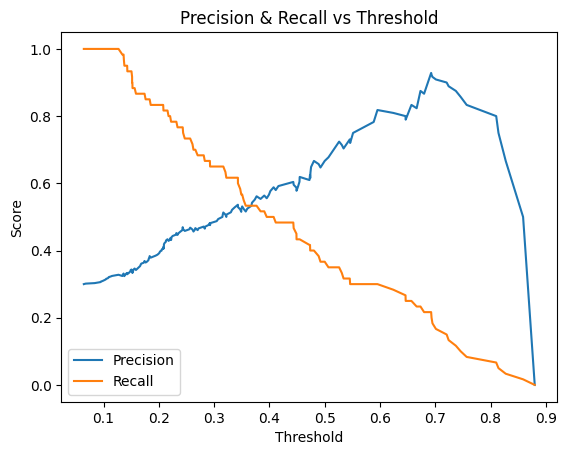

In [ ]:
german_knn_set1 = KNeighborsClassifier(leaf_size= 35, metric= 'minkowski', n_neighbors= 30, p= 2, weights= 'distance')

# german_knn_final = KNeighborsClassifier(leaf_size= 35, metric= 'minkowski', n_neighbors= 30, p= 2, weights= 'distance')
german_knn_set1.fit(X_train_preprocessed,y_train)

metrics, feature_importance = evaluate_model(
        model=german_svm_set1,
        X_train=X_train_preprocessed,
        y_train=y_train,
        X_test=X_test_preprocessed,
        y_test=y_test,
        threshold=0.35
)

In [ ]:
metrics

,Model_Evaluation
class_weight_train,"Risk\n0 0.7\n1 0.3\nName: proportion, dt..."
class_weight_test,"Risk\n0 0.7\n1 0.3\nName: proportion, dt..."
ROC_AUC_train,0.829613
ROC_AUC_test,0.745536
Gini,0.491071
PR_AUC,0.58813
KS,0.395238
LogLoss,0.518816
BrierScore,0.170491
Accuracy,0.72


# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

german_dt = DecisionTreeClassifier()
kf = KFold(n_splits=5,shuffle=True, random_state=2)

In [ ]:
from scipy.stats import randint

dt_para_set1 = {

    "max_depth": [5,7],

    "min_samples_split": randint(2, 20),

    "min_samples_leaf": randint(1, 20),

    "max_features": [None, "sqrt", "log2"],

    "criterion": ["gini", "entropy", "log_loss"]
}
dt_para_set2 = {

    "max_depth": [5,6,7,8],

    "min_samples_split": [5,8,10,12,15],

    "min_samples_leaf": [12,16, 18,19, 20],

    "max_features": [None],

    "criterion": ["gini", "entropy", "log_loss"]
}

In [ ]:
random_grid = RandomizedSearchCV(german_dt,
                                 dt_para_set1,
                                 n_iter=100,
                                 scoring='roc_auc',
                                 cv=kf,verbose=1)

random_grid.fit(X_train_preprocessed,y_train)

results = pd.DataFrame(random_grid.cv_results_)
results.sort_values(by='mean_test_score',ascending=False).head(10)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
95,0.004004,0.000113,0.003116,0.000050,entropy,7,None,18,14,"{'criterion': 'entropy', 'max_depth': 7, 'max_...",0.722651,0.739407,0.696510,0.729362,0.767943,0.731175,0.023226,1
90,0.004189,0.000260,0.003387,0.000325,gini,7,None,3,13,"{'criterion': 'gini', 'max_depth': 7, 'max_fea...",0.725381,0.721045,0.729024,0.744254,0.712569,0.726455,0.010456,2
8,0.011546,0.000940,0.011614,0.001879,gini,7,None,19,2,"{'criterion': 'gini', 'max_depth': 7, 'max_fea...",0.694690,0.736279,0.740275,0.712079,0.748455,0.726356,0.019935,3
99,0.004097,0.000072,0.003351,0.000234,gini,7,None,3,8,"{'criterion': 'gini', 'max_depth': 7, 'max_fea...",0.710601,0.724980,0.733124,0.760618,0.699605,0.725785,0.020899,4
52,0.006698,0.001647,0.005146,0.000229,gini,7,None,19,8,"{'criterion': 'gini', 'max_depth': 7, 'max_fea...",0.689230,0.736279,0.740275,0.712079,0.748455,0.725264,0.021711,5
47,0.004552,0.000186,0.005122,0.000295,entropy,7,sqrt,12,13,"{'criterion': 'entropy', 'max_depth': 7, 'max_...",0.697232,0.775827,0.695080,0.744163,0.696686,0.721798,0.032764,6
34,0.008104,0.003091,0.007135,0.003036,gini,7,None,17,6,"{'criterion': 'gini', 'max_depth': 7, 'max_fea...",0.688947,0.719734,0.749428,0.708586,0.738925,0.721124,0.021506,7
84,0.003987,0.000150,0.003233,0.000196,log_loss,7,None,17,7,"{'criterion': 'log_loss', 'max_depth': 7, 'max...",0.731407,0.710149,0.702613,0.720997,0.739955,0.721024,0.013590,8
49,0.005121,0.000312,0.005349,0.000428,log_loss,7,log2,12,17,"{'criterion': 'log_loss', 'max_depth': 7, 'max...",0.669365,0.782082,0.682971,0.770914,0.699004,0.720867,0.046516,9
83,0.004157,0.000139,0.003662,0.000347,entropy,7,None,17,18,"{'criterion': 'entropy', 'max_depth': 7, 'max_...",0.723216,0.710149,0.702613,0.720997,0.743304,0.720056,0.013811,10


In [ ]:
gridsearch = GridSearchCV(german_dt,dt_para_set2,scoring='roc_auc',cv=kf,verbose=1)
gridsearch.fit(X_train_preprocessed,y_train)

results = pd.DataFrame(gridsearch.cv_results_)
results.sort_values(by='mean_test_score',ascending=False).head(10)

Fitting 5 folds for each of 300 candidates, totalling 1500 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
272,0.003959,0.000280,0.003306,0.000369,log_loss,7,None,20,10,"{'criterion': 'log_loss', 'max_depth': 7, 'max...",0.720203,0.731739,0.705664,0.744622,0.756525,0.731751,0.017851,1
19,0.012473,0.000148,0.013677,0.001578,gini,5,None,19,15,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.706647,0.748789,0.726163,0.715481,0.761590,0.731734,0.020527,2
15,0.013344,0.002250,0.011997,0.000386,gini,5,None,19,5,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.706647,0.748789,0.726163,0.715481,0.761590,0.731734,0.020527,2
17,0.015623,0.004297,0.013504,0.002025,gini,5,None,19,10,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.706647,0.748789,0.726163,0.715481,0.761590,0.731734,0.020527,2
18,0.013798,0.003512,0.014929,0.002929,gini,5,None,19,12,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.706647,0.748789,0.726163,0.715481,0.761590,0.731734,0.020527,2
16,0.014613,0.001957,0.014220,0.002292,gini,5,None,19,8,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.706647,0.748789,0.726163,0.715481,0.761590,0.731734,0.020527,2
265,0.004246,0.000307,0.003571,0.000711,log_loss,7,None,19,5,"{'criterion': 'log_loss', 'max_depth': 7, 'max...",0.722839,0.736279,0.699561,0.735429,0.764251,0.731672,0.021004,7
270,0.005336,0.000716,0.004368,0.001036,log_loss,7,None,20,5,"{'criterion': 'log_loss', 'max_depth': 7, 'max...",0.717191,0.731739,0.705664,0.747012,0.756525,0.731626,0.018650,8
171,0.004004,0.000122,0.003156,0.000107,entropy,7,None,20,8,"{'criterion': 'entropy', 'max_depth': 7, 'max_...",0.720203,0.730630,0.705664,0.744622,0.756525,0.731529,0.017857,9
274,0.003726,0.000040,0.003002,0.000084,log_loss,7,None,20,15,"{'criterion': 'log_loss', 'max_depth': 7, 'max...",0.720203,0.730630,0.705664,0.744622,0.756525,0.731529,0.017857,9


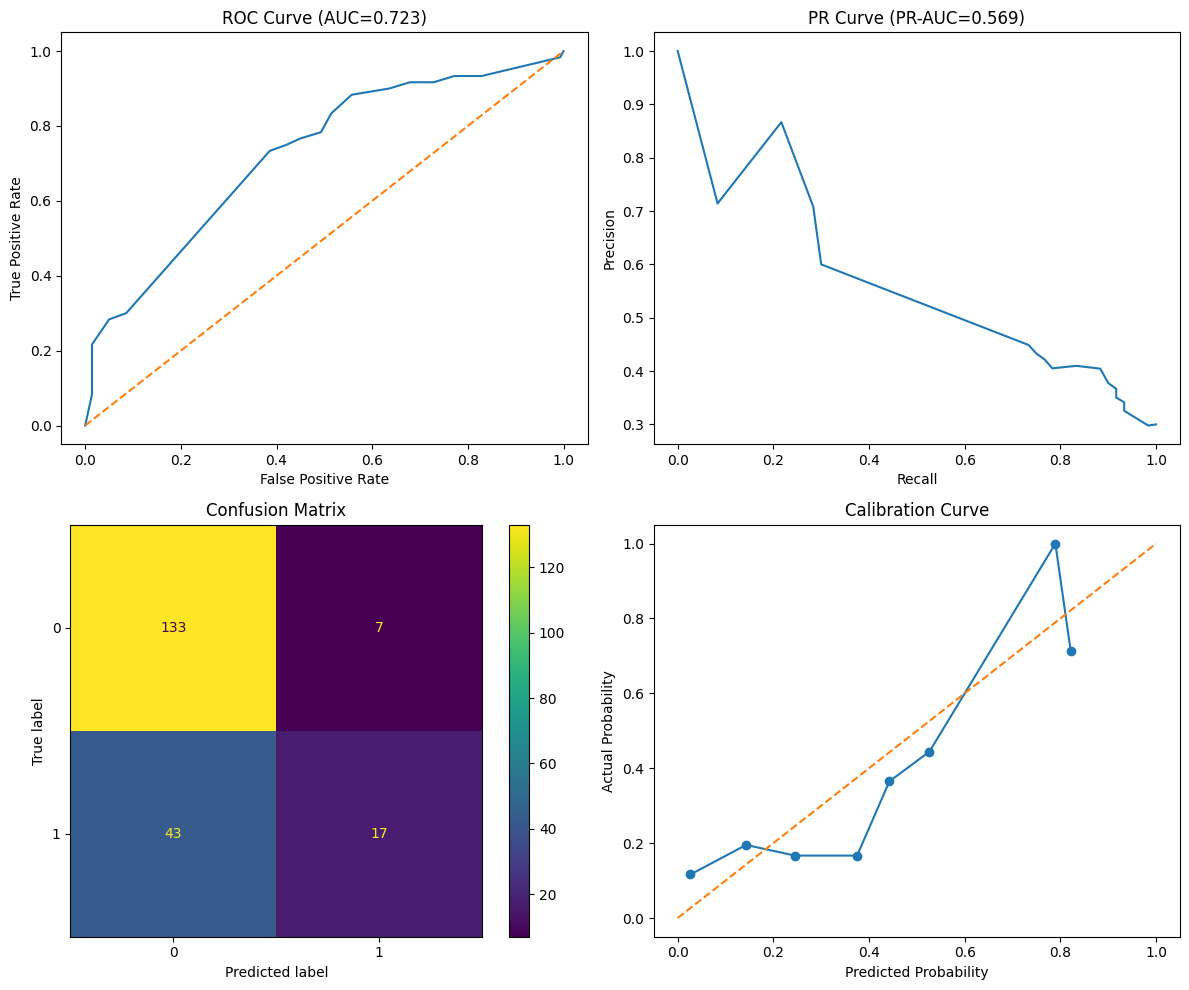

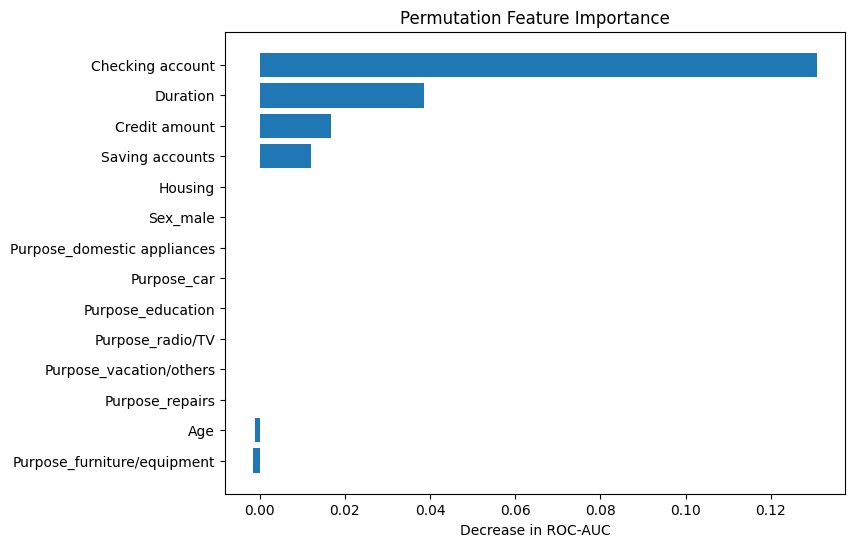

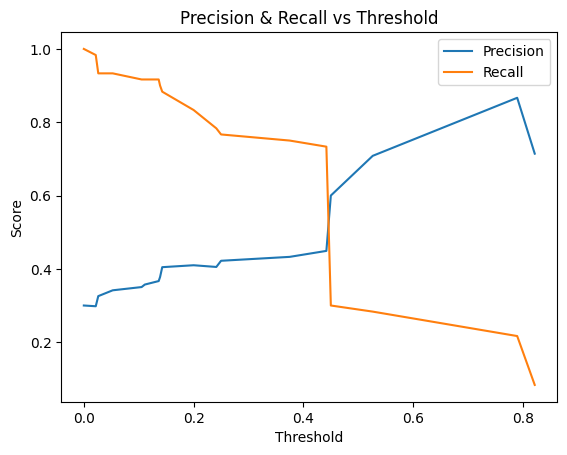

In [ ]:
german_dt_set1 = DecisionTreeClassifier(criterion='log_loss',max_depth= 7,min_samples_leaf= 20, min_samples_split= 10)

german_dt_set2 = DecisionTreeClassifier(criterion='gini', max_depth= 5, min_samples_leaf= 19, min_samples_split= 15)
# german_dt_final = DecisionTreeClassifier(criterion='log_loss',max_depth= 7,min_samples_leaf= 20, min_samples_split= 10)

german_dt_set1.fit(X_train_preprocessed,y_train)
german_dt_set2.fit(X_train_preprocessed,y_train)

metrics, feature_importance = evaluate_model(
        model=german_dt_set2,
        X_train=X_train_preprocessed,
        y_train=y_train,
        X_test=X_test_preprocessed,
        y_test=y_test,
        threshold=0.5
)

In [ ]:
metrics

,Model_Evaluation
class_weight_train,"Risk\n0 0.7\n1 0.3\nName: proportion, dt..."
class_weight_test,"Risk\n0 0.7\n1 0.3\nName: proportion, dt..."
ROC_AUC_train,0.802805
ROC_AUC_test,0.738988
Gini,0.477976
PR_AUC,0.614485
KS,0.37619
LogLoss,1.023496
BrierScore,0.178302
Accuracy,0.65


# Random Forest


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

german_rf = RandomForestClassifier()
kf = KFold(n_splits=5,shuffle=True, random_state=2)

In [ ]:
from scipy.stats import randint

rf_para_set1 = {

    "n_estimators": [50,100,150,200,250,300],

    "max_depth": [None] + list(range(5, 30)),

    "min_samples_split": [2,4,6,8,10,12,15,18,20],

    "min_samples_leaf": [1,2,4,6,8,10,12,15,18,20],

    "max_features": ["sqrt", "log2", None],

    "bootstrap": [True, False],

    "class_weight": [None, "balanced"]
}

rf_para_set2 = {

    "n_estimators": [100,150,200],

    "max_depth": [None] + [4,5,6],

    "min_samples_split": [6,7,8,9,10,11,12],

    "min_samples_leaf": [1,2,3,4,5,6],

    "max_features": [None],

    "bootstrap": [True],

    "class_weight": [None, "balanced"]
}

In [ ]:
random_grid = RandomizedSearchCV(german_rf,
                                 rf_para_set2,
                                 n_iter=100,
                                 scoring='roc_auc',
                                 cv=kf,verbose=1)

random_grid.fit(X_train_preprocessed,y_train)

results = pd.DataFrame(random_grid.cv_results_)
results.sort_values(by='mean_test_score',ascending=False).head(10)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_min_samples_leaf,param_max_features,param_max_depth,param_class_weight,param_bootstrap,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
13,0.253892,0.006541,0.011819,0.000348,100,6,1,None,5,None,True,"{'n_estimators': 100, 'min_samples_split': 6, ...",0.746940,0.830105,0.756484,0.763192,0.783139,0.775972,0.029556,1
95,0.339052,0.068149,0.013455,0.002075,100,8,4,None,10,None,True,"{'n_estimators': 100, 'min_samples_split': 8, ...",0.754095,0.837974,0.736651,0.764111,0.759100,0.770386,0.035038,2
60,0.352268,0.006712,0.015339,0.000289,150,10,1,None,4,balanced,True,"{'n_estimators': 150, 'min_samples_split': 10,...",0.741103,0.808515,0.765446,0.767420,0.768372,0.770171,0.021672,3
51,1.253887,0.633867,0.030381,0.004842,300,4,1,None,6,balanced,True,"{'n_estimators': 300, 'min_samples_split': 4, ...",0.741103,0.811743,0.766018,0.764295,0.767342,0.770100,0.022947,4
50,0.845391,0.184122,0.033345,0.010211,275,20,1,None,5,balanced,True,"{'n_estimators': 275, 'min_samples_split': 20,...",0.746564,0.806901,0.754958,0.767420,0.771291,0.769427,0.020707,5
80,0.414701,0.006420,0.018918,0.001152,100,8,7,None,6,None,True,"{'n_estimators': 100, 'min_samples_split': 8, ...",0.741668,0.827482,0.745995,0.762456,0.764080,0.768336,0.030858,6
43,0.497379,0.011211,0.020366,0.001064,200,15,7,None,5,None,True,"{'n_estimators': 200, 'min_samples_split': 15,...",0.738279,0.823648,0.741419,0.765030,0.769231,0.767521,0.030646,7
96,0.967935,0.112479,0.031549,0.005238,225,8,4,None,7,None,True,"{'n_estimators': 225, 'min_samples_split': 8, ...",0.746564,0.821630,0.735507,0.770546,0.759959,0.766841,0.029853,8
3,0.740948,0.011720,0.026358,0.000610,275,18,6,None,7,None,True,"{'n_estimators': 275, 'min_samples_split': 18,...",0.742798,0.828289,0.733791,0.762640,0.762191,0.765942,0.033110,9
81,0.863717,0.084380,0.026937,0.000493,275,20,1,None,10,balanced,True,"{'n_estimators': 275, 'min_samples_split': 20,...",0.751836,0.810533,0.749428,0.749770,0.766312,0.765576,0.023328,10


In [ ]:
gridsearch = GridSearchCV(german_rf,rf_para_set2,scoring='roc_auc',cv=kf,verbose=1)
gridsearch.fit(X_train_preprocessed,y_train)

results = pd.DataFrame(gridsearch.cv_results_)
results.sort_values(by='mean_test_score',ascending=False).head(10)

Fitting 5 folds for each of 1008 candidates, totalling 5040 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_bootstrap,param_class_weight,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
267,0.301532,0.067966,0.014080,0.003073,True,None,5,None,1,11,100,"{'bootstrap': True, 'class_weight': None, 'max...",0.755413,0.827684,0.755530,0.766133,0.790179,0.778988,0.027451,1
266,0.513798,0.011360,0.020152,0.000418,True,None,5,None,1,10,200,"{'bootstrap': True, 'class_weight': None, 'max...",0.753342,0.825262,0.750572,0.770546,0.791724,0.778289,0.027704,2
388,1.034790,0.229060,0.038171,0.018368,True,None,6,None,1,9,150,"{'bootstrap': True, 'class_weight': None, 'max...",0.757861,0.833939,0.753623,0.767420,0.777644,0.778098,0.029124,3
379,0.590090,0.117610,0.023925,0.004722,True,None,6,None,1,6,150,"{'bootstrap': True, 'class_weight': None, 'max...",0.759179,0.824859,0.758581,0.764295,0.782967,0.777976,0.025058,4
264,0.255971,0.009425,0.011925,0.000293,True,None,5,None,1,10,100,"{'bootstrap': True, 'class_weight': None, 'max...",0.751459,0.832123,0.745995,0.773855,0.783482,0.777383,0.030670,5
410,0.547348,0.004382,0.020526,0.000631,True,None,6,None,2,9,200,"{'bootstrap': True, 'class_weight': None, 'max...",0.753719,0.831316,0.745995,0.775142,0.780391,0.777313,0.029893,6
285,0.260285,0.011336,0.012634,0.000865,True,None,5,None,2,10,100,"{'bootstrap': True, 'class_weight': None, 'max...",0.748447,0.823245,0.762967,0.769443,0.781250,0.777070,0.025400,7
263,0.505496,0.012604,0.023872,0.005182,True,None,5,None,1,9,200,"{'bootstrap': True, 'class_weight': None, 'max...",0.752212,0.821832,0.756865,0.770730,0.783139,0.776956,0.024927,8
390,0.618736,0.148923,0.019601,0.003455,True,None,6,None,1,10,100,"{'bootstrap': True, 'class_weight': None, 'max...",0.754095,0.828491,0.747140,0.767053,0.787946,0.776945,0.029279,9
402,0.449512,0.012281,0.018027,0.000665,True,None,6,None,2,7,100,"{'bootstrap': True, 'class_weight': None, 'max...",0.750894,0.831517,0.745042,0.767788,0.788633,0.776775,0.031289,10


In [ ]:
# param_bootstrap	param_class_weight	param_max_depth	param_max_features	param_min_samples_leaf	param_min_samples_split	param_n_estimators
# True	None	5	None	1	11	100
# True	None	5	None	1	10	200
# True	None	6	None	1	9	150
# True	None	6	None	1	6	150
# True	None	5	None	1	10	100
# True	None	6	None	2	9	200
# True	None	5	None	2	10	100
# True	None	5	None	1	9	200
# n_estimators=100, max_depth = 5,min_samples_split = 11, min_samples_leaf = 1, max_features = None,bootstrap=True, class_weight = None
german_rf_set1 = RandomForestClassifier(n_estimators=100, max_depth = 5,min_samples_split = 11, min_samples_leaf = 1, max_features = None,bootstrap=True, class_weight = None)

# german_dt_set2 = DecisionTreeClassifier(criterion='gini', max_depth= 5, min_samples_leaf= 19, min_samples_split= 15)
# german_dt_final = DecisionTreeClassifier(criterion='log_loss',max_depth= 7,min_samples_leaf= 20, min_samples_split= 10)

german_dt_set1.fit(X_train_preprocessed,y_train)
# german_dt_set2.fit(X_train_preprocessed,y_train)

metrics, feature_importance = evaluate_model(
        model=german_dt_set2,
        X_train=X_train_preprocessed,
        y_train=y_train,
        X_test=X_test_preprocessed,
        y_test=y_test,
        threshold=0.5
)

# Optuna

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.4 MB/s eta 0:00:00


In [ ]:
import optuna
import numpy as np

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

def get_model(trial, model_name):

  if model_name == "logistic":

    solver = trial.suggest_categorical(
        "solver", ["saga", "liblinear", "lbfgs", "newton-cg"]
    )

    C = trial.suggest_float("C", 1e-2, 1e2, log=True)

    class_weight = trial.suggest_categorical(
        "class_weight", ["balanced", None]
    )

    if solver == "saga":

        penalty = "elasticnet"

        l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)

    elif solver == "liblinear":

        penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
        l1_ratio = None

    elif solver in ["lbfgs", "newton-cg"]:

        penalty = "l2"
        l1_ratio = None

    model = LogisticRegression(
            solver=solver,
            penalty=penalty,
            C=C,
            l1_ratio=l1_ratio,
            class_weight=class_weight,
            max_iter=1000
        )

  elif model_name == "svm":

    kernel = trial.suggest_categorical("kernel", ["linear", "rbf"])

    # Common parameter
    C = trial.suggest_float("C", 1e-3, 1e3, log=True)

    if kernel == "rbf":

        gamma = trial.suggest_float("gamma", 1e-4, 1, log=True)

    else:
        gamma = "scale"

    model = SVC(
            kernel=kernel,
            C=C,
            gamma=gamma,
            probability=True
        )


  elif model_name == "knn":

        n_neighbors = trial.suggest_int("n_neighbors", 3, 50)
        leaf_size = trial.suggest_int("leaf_size", 5, 50)
        weights = trial.suggest_categorical("weights", ["uniform", "distance"])
        p = trial.suggest_categorical("p", [1, 2])


        model = KNeighborsClassifier(
                n_neighbors=n_neighbors,
                weights=weights,
                p=p,
                leaf_size = leaf_size
            )


  elif model_name == "decision_tree":

        max_depth = trial.suggest_int("max_depth", 3, 30)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_features = trial.suggest_categorical("max_features", [None, "sqrt", "log2"])
        criterion = trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"])

        model = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            criterion=criterion
        )


  elif model_name == "random_forest":

        n_estimators = trial.suggest_int("n_estimators", 50, 400)
        max_depth = trial.suggest_int("max_depth", 5, 25)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
        bootstrap = trial.suggest_categorical("bootstrap", [True, False])
        class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            min_samples_split=min_samples_split,
            max_features=max_features,
            bootstrap=bootstrap,
            class_weight=class_weight,
            n_jobs=-1
        )


  elif model_name == "xgboost":

    n_estimators = trial.suggest_int("n_estimators", 100, 500)

    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)

    max_depth = trial.suggest_int("max_depth", 4, 12)

    min_child_weight = trial.suggest_int("min_child_weight", 1, 10)

    subsample = trial.suggest_float("subsample", 0.6, 1.0)

    colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0)

    gamma = trial.suggest_float("gamma", 0.0, 5.0)

    reg_alpha = trial.suggest_float("reg_alpha", 1e-3, 10, log=True)

    reg_lambda = trial.suggest_float("reg_lambda", 1e-3, 10, log=True)

    scale_pos_weight = trial.suggest_categorical(
        "scale_pos_weight", [1, 2, 3, 5]
    )

    model = XGBClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        gamma=gamma,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        use_label_encoder=False,
        n_jobs=-1
    )

  else:
      raise ValueError("Invalid model name")

  return model

In [ ]:
def objective(trial, model_name, X_train, y_train):

    model = get_model(trial, model_name)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    return score

In [ ]:
def tune_model(model_name, X_train, y_train, n_trials=30):

    study = optuna.create_study(direction="maximize")

    study.optimize(
        lambda trial: objective(trial, model_name, X_train, y_train),
        n_trials=n_trials
    )

    return study

In [ ]:
import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_contour,
    plot_slice
)


def plot_optuna_diagnostics(study, plots=None):
    """
    Plots key Optuna diagnostic graphs.

    Parameters:
    ----------
    study : optuna.study.Study
        Completed Optuna study

    plots : list (optional)
        List of plots to generate. Options:
        ["history", "importance", "parallel", "contour", "slice"]
        Default = all
    """

    if plots is None:
        plots = ["history", "importance", "parallel", "contour", "slice"]

    print("\n📊 Optuna Study Diagnostics\n")

    # 1. Optimization History
    if "history" in plots:
        print("▶ Optimization History")
        fig = plot_optimization_history(study)
        fig.show()

    # 2. Parameter Importance
    if "importance" in plots:
        print("▶ Parameter Importance")
        fig = plot_param_importances(study)
        fig.show()

    # 3. Parallel Coordinate Plot
    if "parallel" in plots:
        print("▶ Parallel Coordinate Plot")
        fig = plot_parallel_coordinate(study)
        fig.show()

    # 4. Contour Plot (interaction between params)
    if "contour" in plots:
        print("▶ Contour Plot")
        fig = plot_contour(study)
        fig.show()

    # 5. Slice Plot (individual param vs objective)
    if "slice" in plots:
        print("▶ Slice Plot")
        fig = plot_slice(study)
        fig.show()

In [ ]:
study = tune_model('logistic', X_train_preprocessed, y_train, n_trials=100)

[I 2026-03-31 15:16:27,480] A new study created in memory with name: no-name-422b28c3-05c6-4c1d-b006-961ab49b0d68
[I 2026-03-31 15:16:33,483] Trial 0 finished with value: 0.9273872150486211 and parameters: {'solver': 'saga', 'C': 17.887982202583142, 'class_weight': 'balanced', 'l1_ratio': 0.660138783292974}. Best is trial 0 with value: 0.9273872150486211.
[I 2026-03-31 15:16:33,581] Trial 1 finished with value: 0.895783516658696 and parameters: {'solver': 'lbfgs', 'C': 0.015917351641260073, 'class_weight': None}. Best is trial 0 with value: 0.9273872150486211.
[I 2026-03-31 15:16:34,310] Trial 2 finished with value: 0.9286226685796269 and parameters: {'solver': 'saga', 'C': 2.2027337570416297, 'class_weight': 'balanced', 'l1_ratio': 0.20955530364206731}. Best is trial 2 with value: 0.9286226685796269.
[I 2026-03-31 15:16:34,428] Trial 3 finished with value: 0.7156264945002392 and parameters: {'solver': 'saga', 'C': 0.010789736974915299, 'class_weight': 'balanced', 'l1_ratio': 0.9996166

In [ ]:
print("Best Score:", study.best_value)
print("Best Params:", study.best_params)

plot_optuna_diagnostics(study)

Best Score: 0.9339032360911844
Best Params: {'solver': 'saga', 'C': 0.13284220004920463, 'class_weight': None, 'l1_ratio': 0.8669908481379376}

📊 Optuna Study Diagnostics

▶ Optimization History


▶ Parameter Importance


[W 2026-03-31 15:17:15,159] Your study has only completed trials with missing parameters.


▶ Parallel Coordinate Plot


▶ Contour Plot


/tmp/ipykernel_8748/1734169631.py:52: UserWarning:

Contour plot will not be displayed because `l1_ratio` and `penalty` cannot co-exist in `trial.params`.

/tmp/ipykernel_8748/1734169631.py:52: UserWarning:

Contour plot will not be displayed because `penalty` and `l1_ratio` cannot co-exist in `trial.params`.



▶ Slice Plot


In [ ]:
models = [
    "logistic",
    "svm",
    "knn",
    "decision_tree",
    "random_forest",
    "xgboost"
]

all_studies = {}

for model_name in models:

    print(f"\nTuning {model_name}...")

    study = tune_model(model_name, X_train_FS, y_train, n_trials=50)

    all_studies[model_name] = study

    print("Best Score:", study.best_value)
    print("Best Params:", study.best_params)
    plot_optuna_diagnostics(study)

[I 2026-03-31 15:38:19,192] A new study created in memory with name: no-name-f70b39f8-38fc-430b-bf22-c761639fc7d0



Tuning logistic...


[I 2026-03-31 15:38:21,608] Trial 0 finished with value: 0.8253626653913599 and parameters: {'solver': 'liblinear', 'C': 0.01796446219231996, 'class_weight': None, 'penalty': 'l1'}. Best is trial 0 with value: 0.8253626653913599.
[I 2026-03-31 15:38:21,647] Trial 1 finished with value: 0.9246373346086401 and parameters: {'solver': 'newton-cg', 'C': 0.09748595531925412, 'class_weight': None}. Best is trial 1 with value: 0.9246373346086401.
[I 2026-03-31 15:38:21,695] Trial 2 finished with value: 0.9303363621871513 and parameters: {'solver': 'lbfgs', 'C': 0.4078692367357152, 'class_weight': None}. Best is trial 2 with value: 0.9303363621871513.
[I 2026-03-31 15:38:21,835] Trial 3 finished with value: 0.9291407619958552 and parameters: {'solver': 'saga', 'C': 0.11003713823390995, 'class_weight': 'balanced', 'l1_ratio': 0.34878243079043425}. Best is trial 2 with value: 0.9303363621871513.
[I 2026-03-31 15:38:21,866] Trial 4 finished with value: 0.8936712896540729 and parameters: {'solver':

Best Score: 0.933703969392635
Best Params: {'solver': 'saga', 'C': 0.12889798996379476, 'class_weight': None, 'l1_ratio': 0.8333320106531401}

📊 Optuna Study Diagnostics

▶ Optimization History


▶ Parameter Importance


...

Best Score: 0.941296030607365
Best Params: {'n_estimators': 300, 'learning_rate': 0.028692382560967213, 'max_depth': 10, 'min_child_weight': 5, 'subsample': 0.9163591509984774, 'colsample_bytree': 0.8093381421279863, 'gamma': 1.2844585946962992, 'reg_alpha': 0.36977558830467855, 'reg_lambda': 0.06557428559149225, 'scale_pos_weight': 1}

📊 Optuna Study Diagnostics

▶ Optimization History


▶ Parameter Importance


▶ Parallel Coordinate Plot


▶ Contour Plot


▶ Slice Plot


In [ ]:

# rebuild model
best_model.fit(X_train, y_train)

In [ ]:
all_studies['xgboost'].best_params

{'n_estimators': 174,
 'learning_rate': 0.11538343004193466,
 'max_depth': 5,
 'min_child_weight': 2,
 'subsample': 0.7618962442057837,
 'colsample_bytree': 0.6805030052519774,
 'gamma': 2.2300215841034485,
 'reg_alpha': 0.18963926956857718,
 'reg_lambda': 1.3664452945300434,
 'scale_pos_weight': 1}

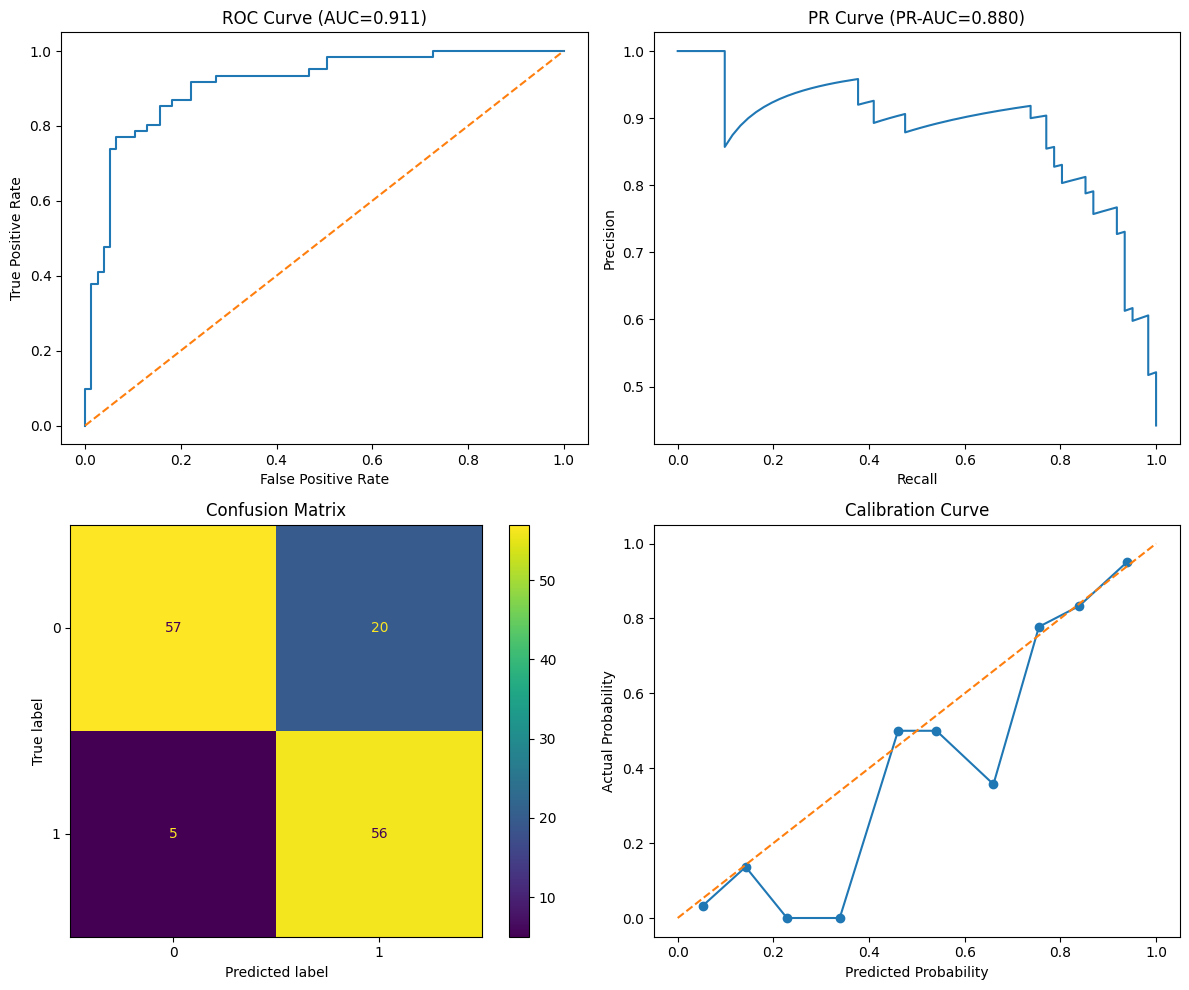

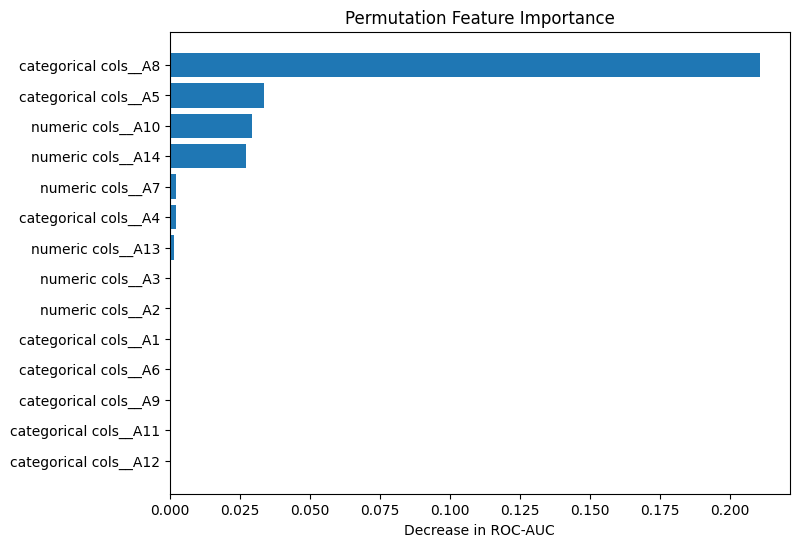

Results saved to /content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx


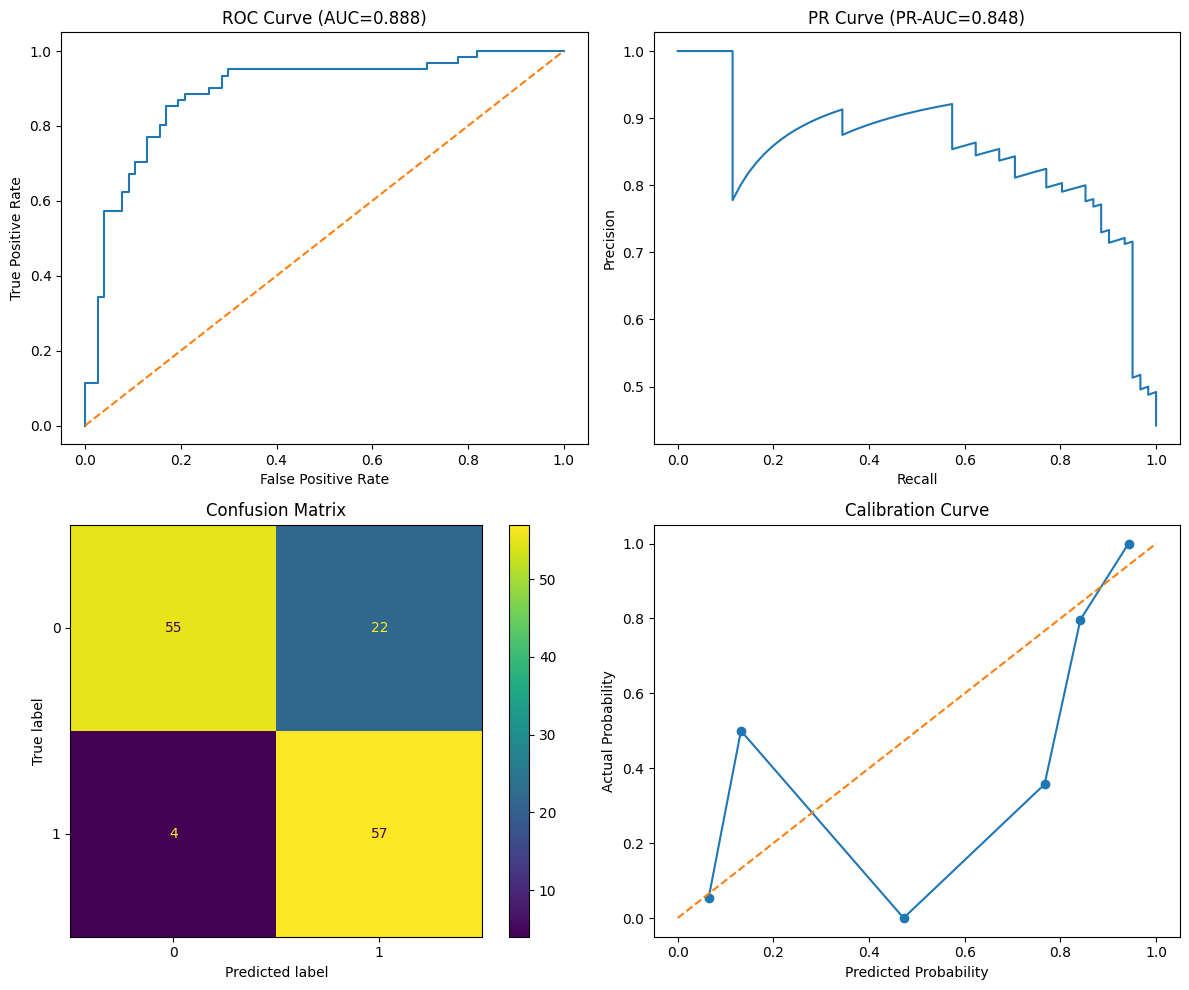

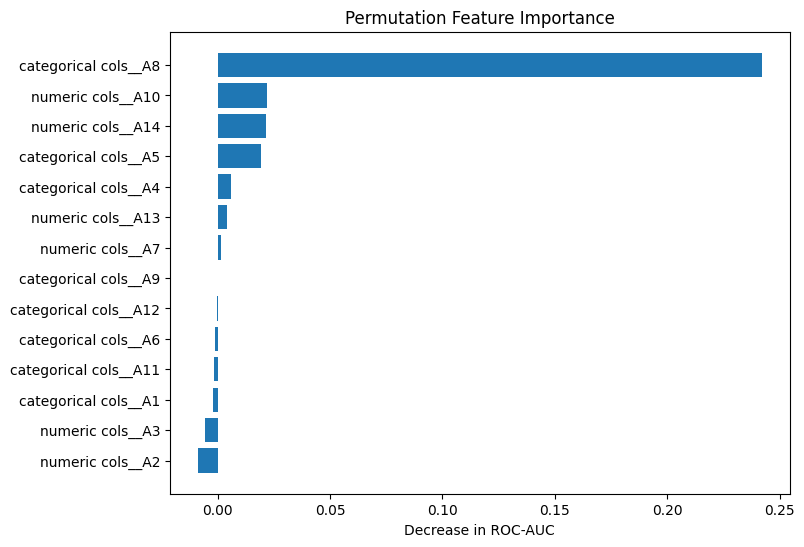

Results saved to /content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx


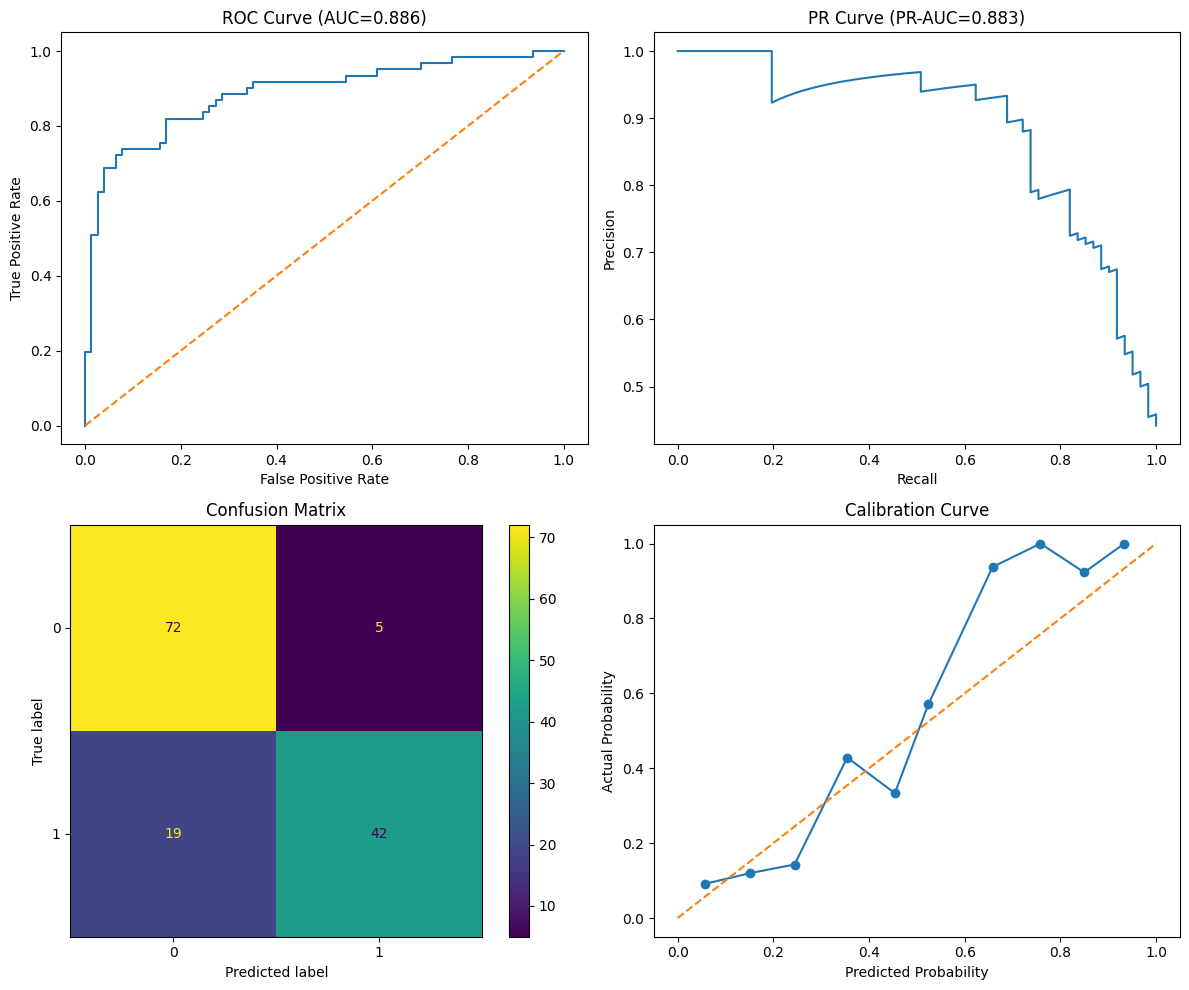

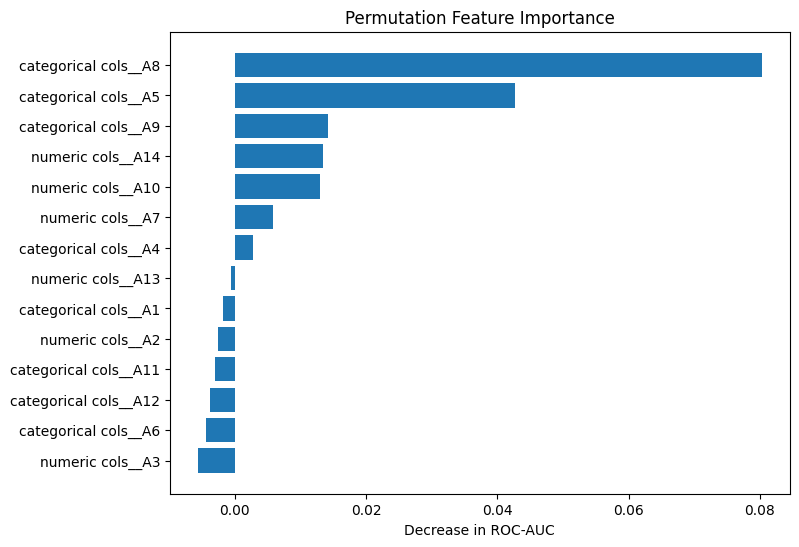

Results saved to /content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx


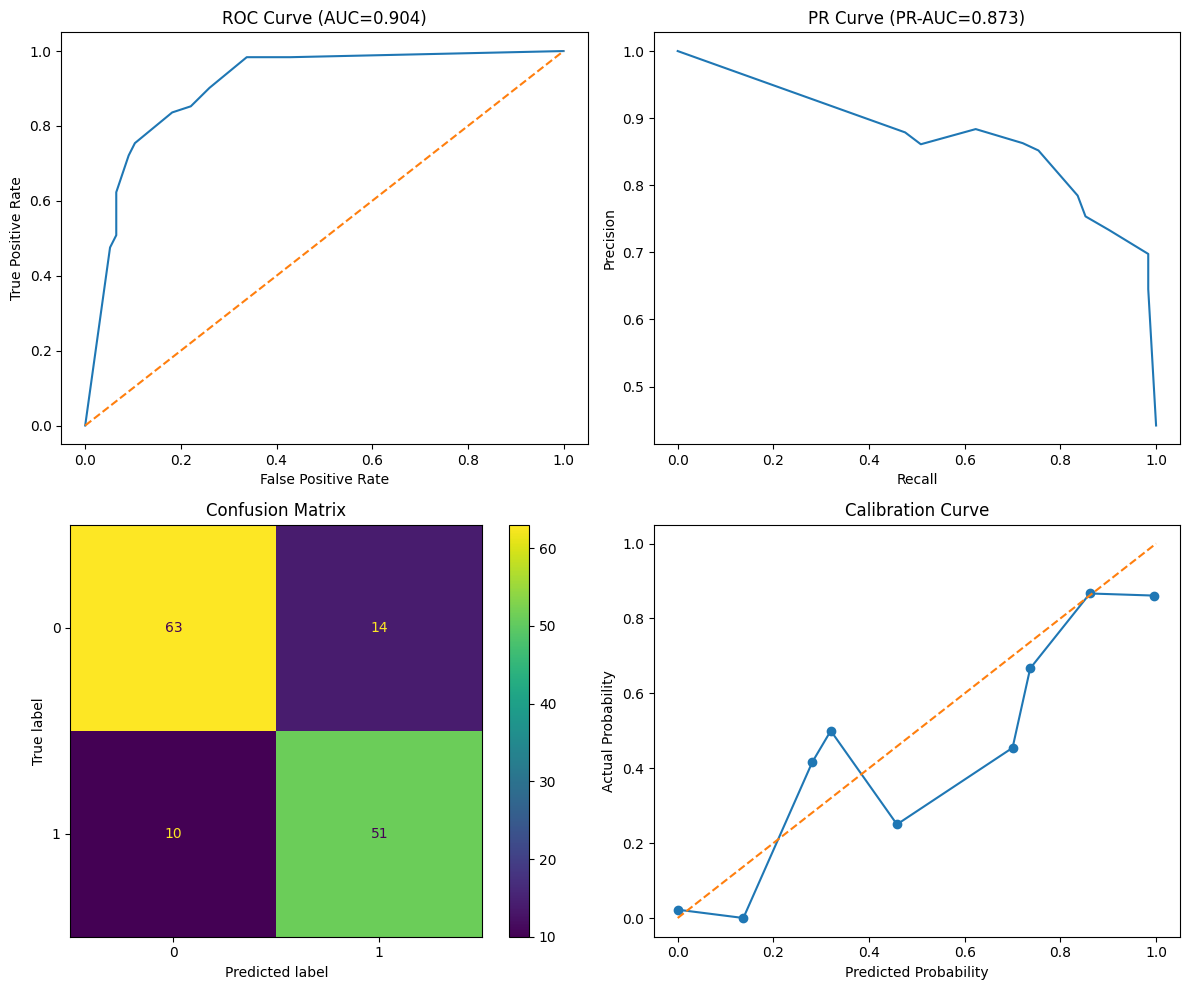

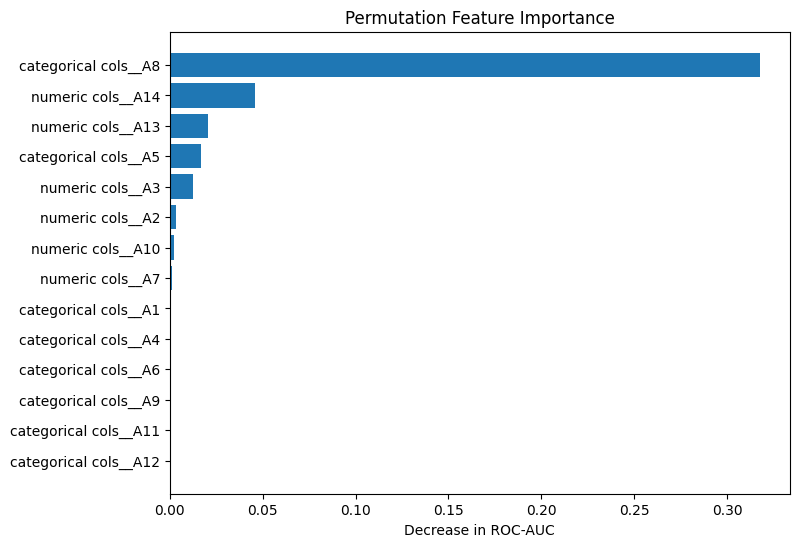

Results saved to /content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx


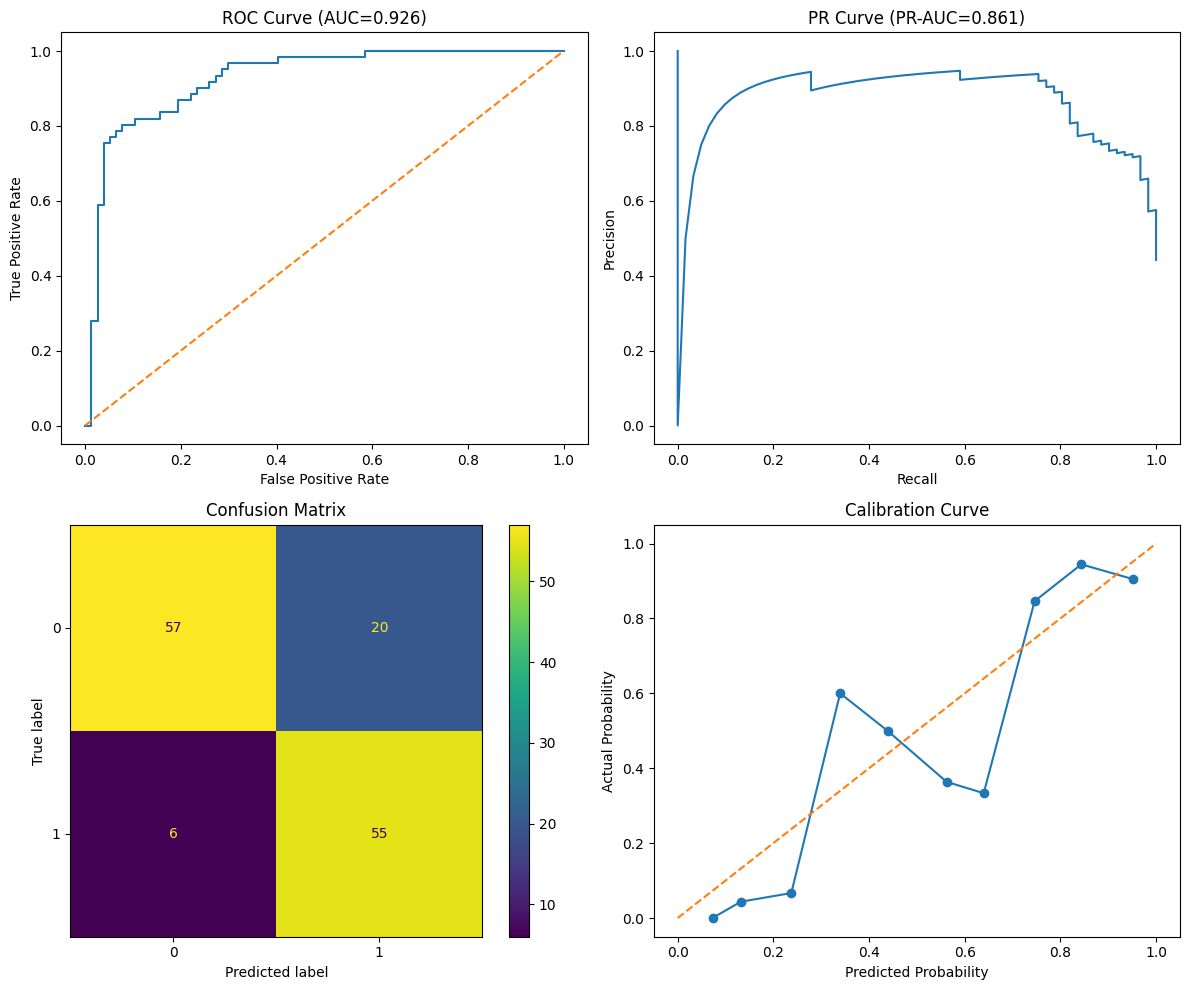

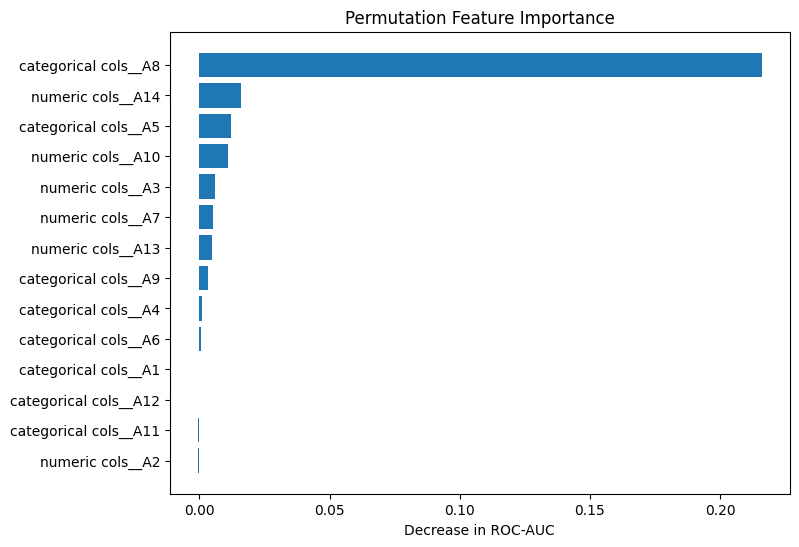

Results saved to /content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[16:07:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




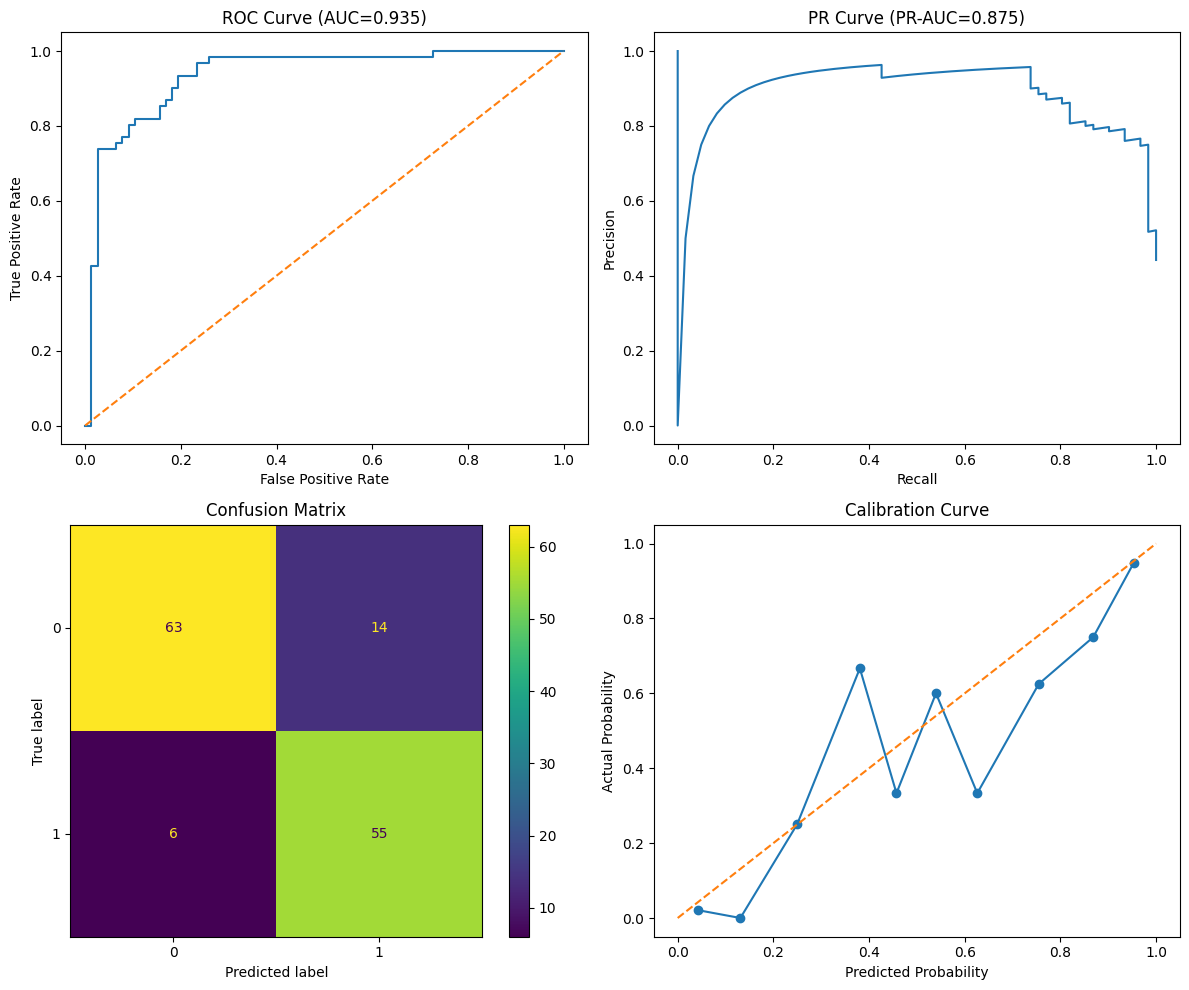

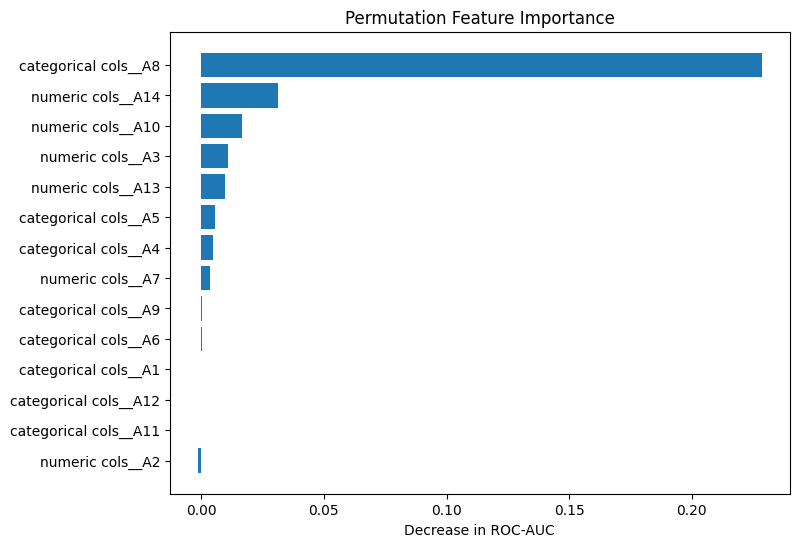

Results saved to /content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx


In [ ]:
models = [
    "logistic",
    "svm",
    "knn",
    "decision_tree",
    "random_forest",
    "xgboost"
]

for model_name in models:
  best_params = all_studies[model_name].best_params
  trial = optuna.trial.FixedTrial(best_params)
  best_model = get_model(trial, model_name)

  best_model.fit(X_train_preprocessed, y_train)

  metrics, feature_importance = evaluate_model(
          model=best_model,
          X_train=X_train_preprocessed,
          y_train=y_train,
          X_test=X_test_preprocessed,
          y_test=y_test
      )

  save_results_to_excel(
        metrics_df=metrics,
        dataset_name="AUS_Credit",
        model_name=f"HPT_{model_name}",
        params=best_model.get_params(),
        comments="Tunned model",
        file_path = '/content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx'
)